# Co-variation analysis

In [1]:
import os
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from anndata import AnnData
from natsort import natsorted
from tqdm.notebook import tqdm
from scipy import stats, sparse
from adjustText import adjust_text
import matplotlib.patches as mpatches

In [2]:
from matplotlib.gridspec import GridSpec
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.sparse import csr_matrix as csr
from scipy.stats import linregress
from scipy.stats import pearsonr, spearmanr
import itertools
import collections

In [3]:
plt.rcParams['pdf.fonttype'] = 42
sc._settings.settings._vector_friendly=True

In [15]:
from datetime import datetime
date = datetime.today().strftime('%Y-%m-%d')

In [4]:
base_path = '/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/expr'

input_path = os.path.join(base_path, 'cell type classification')

out_path = os.path.join(base_path, 'DE analysis/region')
if not os.path.exists(out_path):
    os.mkdir(out_path)
    
fig_path = os.path.join('/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures','manuscript figure','spatial')
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [6]:
adata = sc.read_h5ad(os.path.join(base_path, '2025-04-11-finalized-ct-rgn.h5ad'))

## 1. Filter neurons

In [27]:
obs = adata.obs.loc[adata.obs['level_2'] != 'Mix', :].copy()
df_counts = pd.crosstab(obs['region_label'], obs['level_2'])
df_counts.columns = df_counts.columns.str.split('-').str[0]

<Axes: xlabel='level_2', ylabel='region_label'>

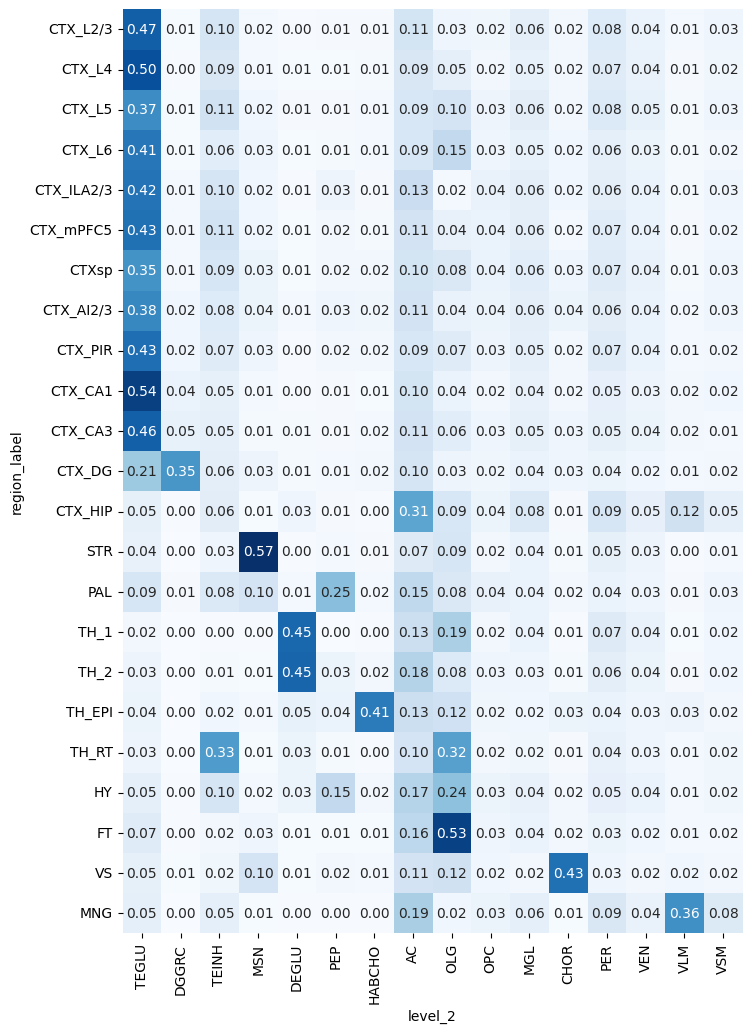

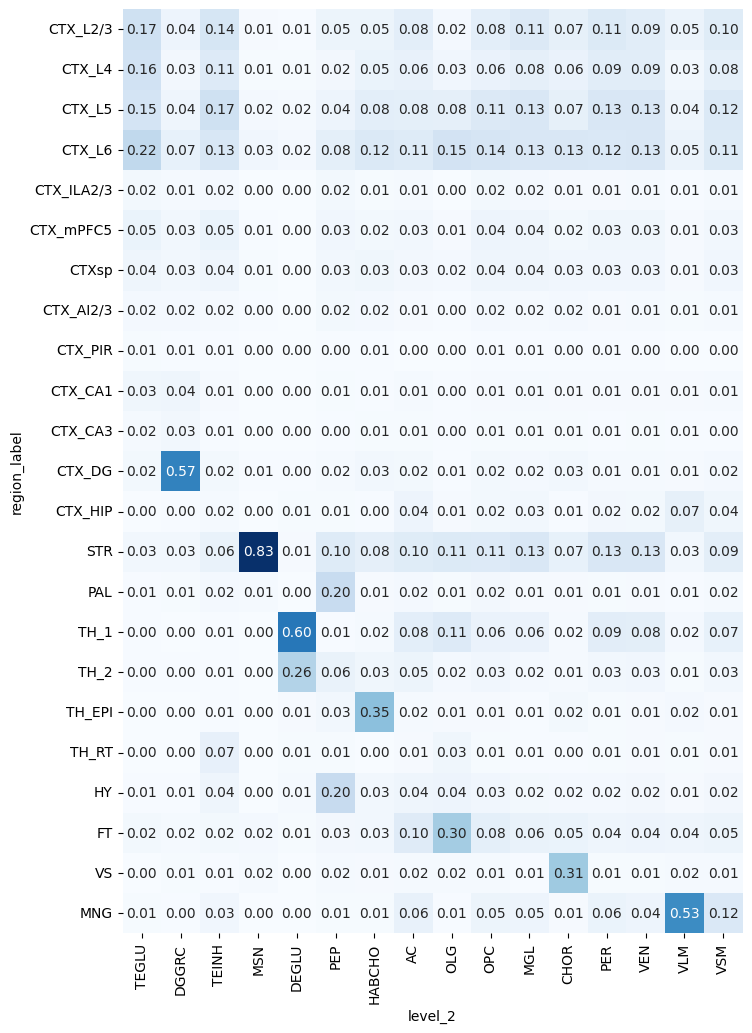

In [31]:
# Normalize across each row to get proportions
df_counts_norm_region = df_counts.div(df_counts.sum(axis=1), axis=0)
df_counts_norm_ctype = df_counts.div(df_counts.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(df_counts_norm_region, cmap='Blues', annot=True, fmt='.2f', cbar=False, ax=ax)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(df_counts_norm_ctype, cmap='Blues', annot=True, fmt='.2f', cbar=False, ax=ax)

In [7]:
region_to_exclude = ['VS','FT','MNG','CTX_HIP','CTX_PIR']

In [8]:
region_ct_dict = {
    'CTX_L2/3': ["TEGLU", "TEINH"],
    'CTX_L4': ["TEGLU", "TEINH"],
    'CTX_L5': ["TEGLU", "TEINH"],
    'CTX_L6': ["TEGLU", "TEINH"],
    'CTX_ILA2/3': ["TEGLU", "TEINH"],
    'CTX_mPFC5': ["TEGLU", "TEINH"],
    'CTXsp': ["TEGLU", "TEINH"],
    'CTX_AI2/3': ["TEGLU", "TEINH"],
    'CTX_CA1': ["TEGLU", "TEINH"],
    'CTX_CA3': ["TEGLU", "TEINH"],
    "CTX_DG": ["TEGLU", "DGGRC", "TEINH"],
    "STR": ["MSN"],
    "PAL": ["PEP"],
    "TH_1": ["DEGLU"],
    "TH_2": ["DEGLU"],
    "TH_EPI": ["HABCHO"],
    "TH_RT": ["TEINH"],
    "HY": ["PEP", "TEINH"],
}

In [9]:
adata.obs['level_3_label']= adata.obs['level_3'].str.split('-').str[0]

In [10]:
# Build a Boolean mask row-by-row
mask = (
    (adata.obs['level_1'] == 'Neuron') &  
    adata.obs.apply(
        lambda r: r['level_2'] in region_ct_dict.get(r['region_label'], []),
        axis=1
    )
)

# Add / overwrite the flag column
adata.obs['spatial_analysis'] = mask
adata.obs['spatial_analysis'].sum()

In [11]:
lvl1_stats = (
    adata.obs['level_1']
    .value_counts(dropna=False) 
    .to_frame('n_cells')
    .assign(percent=lambda x: 100 * x['n_cells'] / len(adata))
    .sort_index()
)
print(lvl1_stats)

         n_cells    percent
level_1                    
Neuron    260694  48.439207
Glia      243624  45.267453
Mix        33870   6.293340


## 2. Calculate region-specific Log2FC

In [21]:
level_2_DEG_dict_filtered = pd.read_excel(os.path.join(base_path,f'DE analysis/nmf/2025-06-18_level_2_nmf_filtered_DEG.xlsx'), sheet_name=None)
level_3_DEG_dict_filtered = pd.read_excel(os.path.join(base_path,f'DE analysis/nmf/2025-06-18_level_3_nmf_filtered_DEG.xlsx'), sheet_name=None)

In [22]:
ct_list = ['AC','OLG','PER']
protocol = 'RIBO'
glial_DEG_dict = {}
for ct in ct_list:
    glial_DEG_dict[ct] = level_2_DEG_dict_filtered[f'{ct}_{protocol}']['names'].to_list()

In [23]:
neuron_ct_list = ['TEGLU','TEINH','MSN','DEGLU','DGGRC','HABCHO','PEP']
neruon_deg_dict = {}
for df in level_3_DEG_dict_filtered:
    if not df.split('_')[0] in neuron_ct_list:
        continue
    if not df.split('_')[-1] == protocol:
        continue
    ct = df[:-5]
    neruon_deg_dict[ct] = level_3_DEG_dict_filtered[df]['names'].to_list()

neuron_deg_list = []
for ct in neruon_deg_dict.keys():
    neuron_deg_list.extend(neruon_deg_dict[ct])
    neuron_deg_list = list(set(neuron_deg_list))

In [24]:
from collections import Counter

gene_counts = Counter()

for gene_list in neruon_deg_dict.values():
    gene_counts.update(set(gene_list)) 

common_neuron_degs = sorted([g for g, n in gene_counts.items() if n >= 3])

print(f"{len(common_neuron_degs)} genes appear in ≥3 neuron cell types")

neuron_deg_list = common_neuron_degs

169 genes appear in ≥3 neuron cell types


In [13]:
ct_list = ['AC','OLG','PER']
protocol   = "RIBO"
genes      = adata.var_names 

ct_dict = {}
for ct in ct_list:
    data_dict = {}
    for rgn in adata.obs["region_label"].unique():
        region_row = {}
        if rgn in region_to_exclude:
            continue

        ad_glia  = adata[(adata.obs["level_2"] == ct)
                    & (adata.obs["region_label"] == rgn)
                    & (adata.obs["protocol"] == protocol)]

        if ad_glia.n_obs == 0:
            continue

        for gene in genes:
            wt_mat  = ad_glia[ad_glia.obs["condition"] == "WT"].layers["log2_norm1e4"][
                        :, adata.var_names == gene
                    ]
            het_mat = ad_glia[ad_glia.obs["condition"] == "HET"].layers["log2_norm1e4"][
                        :, adata.var_names == gene
                    ]

            region_row[gene] = het_mat.mean() - wt_mat.mean()

        data_dict[rgn] = region_row

    logfc_df_ct = (
        pd.DataFrame.from_dict(data_dict, orient="index")
        .rename_axis("region_label")
        .sort_index()
    )
    ct_dict[ct] = logfc_df_ct


In [16]:
out_file = f"{out_path}/{date}_glia_log2FC_by_region_{protocol}.xlsx" 
with pd.ExcelWriter(out_file) as writer:
    for ct, df in ct_dict.items():
        df.index.name = "region_label"
        df.to_excel(writer, sheet_name=ct)

In [17]:
protocol   = "RIBO"
genes      = adata.var_names 

data_dict = {}
for rgn in adata.obs["region_label"].unique():
    region_row = {}
    if rgn in region_to_exclude:
        continue

    ad_neuron  = adata[(adata.obs["spatial_analysis"] == True)
                & (adata.obs["region_label"] == rgn)
                & (adata.obs["protocol"] == protocol)]

    if ad_neuron.n_obs == 0:
        continue

    for gene in genes:
        wt_mat  = ad_neuron[ad_neuron.obs["condition"] == "WT"].layers["log2_norm1e4"][
                    :, adata.var_names == gene
                ]
        het_mat = ad_neuron[ad_neuron.obs["condition"] == "HET"].layers["log2_norm1e4"][
                    :, adata.var_names == gene
                ]

        region_row[gene] = het_mat.mean() - wt_mat.mean()

    data_dict[rgn] = region_row

logfc_df_ct = (
    pd.DataFrame.from_dict(data_dict, orient="index")
    .rename_axis("region_label")
    .sort_index()
)

In [18]:
out_file = f"{out_path}/{date}_neuron_log2FC_by_region_{protocol}.xlsx"
with pd.ExcelWriter(out_file) as writer:
        logfc_df_ct.index.name = "region_label"
        logfc_df_ct.to_excel(writer, sheet_name='Neuron')

In [15]:
# read excel file
ct_dict = pd.read_excel(f"{out_path}/glia_log2FC_by_region_RIBO.xlsx", sheet_name=None, index_col=0)
neuron_df = pd.read_excel(f"{out_path}/neuron_log2FC_by_region_RIBO.xlsx", sheet_name='Neuron', index_col=0)

## 3. Chord Diagram

### 3.1 Import and deine functions

In [69]:
import pycircos
import matplotlib.pyplot as plt
from Bio import SeqIO 
Garc    = pycircos.Garc
Gcircle = pycircos.Gcircle

In [70]:
def tickplot_genelabel(self, garc_id, raxis_range=None, tickinterval=1000, tickpositions=None, ticklabels=None, tickwidth=1, tickcolor="#303030", ticklabelsize=10, ticklabelcolor="#303030", ticklabelmargin=10, tickdirection="outer", ticklabelorientation="vertical"):
        """
        Plot ticks on the arc of the Garc class object
        
        Parameters
        ----------
        garc_id : str 
            ID of the Garc class object. The ID should be in Gcircle object.garc_dict. 
        raxis_range : tuple (top=int, bottom=int)
            Radial axis range where tick plot is drawn.  
            If direction is "inner", the default is `(r0 - 0.5 * abs(r1 -r0), r0)`.  
            If direction is "outer", the default is `(r1, r1 + 0.5 * abs(r1 -r0))`.  
            `r0, r1 = Garc_object.raxis_range[0], Garc_object.raxis_range[1]`
        tickinterval : int
            Tick interval.
            The default is 1000. If `tickpositions` value is given, this value will be ignored.
        tickpositions : list of int 
            Positions on the arc of the Garc class object. 
            If you set ticks on your specified positions, please use this parameter instead of tickinterval
            The values should be less than `Garc_object.size`.
        ticklabels : list of int or list or str
            Labels for ticks on the arc of the Garc class object.
            The default is same with tickpositions.
        tickwidth : float
            Tick width. The default is 1.0.
        tickcolor : str or float representing color code
            Tick color. The default is "#303030"
        ticklabelsize : float
            Tick label fontsize. The default is 10.
        ticklabelcolor : str
            Tick label color, The default is "#303030".
        ticklabelmargin : float
            Tick label margin. The default is 10.
        tickdirection : str ("outer" or "inner")
            Tick direction. The default is "outer".
        ticklabelorientation : str ("vertical" or "horizontal")
            Tick label orientation. The default is "vertical".
        
        Returns
        -------
        None
        """
        start = self._garc_dict[garc_id].coordinates[0] 
        end   = self._garc_dict[garc_id].coordinates[-1]
        size  = self._garc_dict[garc_id].size*2 + 1 # include positions at the center of each gene
        positions_all = np.linspace(start, end, size, endpoint=True)
        
        if raxis_range is None:
            r0, r1 = self._garc_dict[garc_id].raxis_range
            tickheight = 0.5 * abs(r1 - r0)
            if tickdirection == "outer":
                raxis_range = (r1, r1 + tickheight)
            elif tickdirection == "inner":
                raxis_range = (r0 - tickheight, r0)

        if tickpositions is None:
            tickpositions = [pos for pos in range(0, size, tickinterval)]

        if ticklabels is None:
            ticklabels = [None] * len(tickpositions) 
        
        elif ticklabels == "None":
            ticklabels = tickpositions 
        
        for pos, label in zip(tickpositions, ticklabels):
            pos = pos*2+1  # convert to the position in positions_all
            self.ax.plot([positions_all[pos], positions_all[pos]], raxis_range, linewidth=tickwidth, color=tickcolor)
            if label is None:
                pass 
            else:
                ticklabel_rot = self._get_label_rotation(start + ((end - start) * (pos / size)), ticklabelorientation)
                if ticklabelorientation == "horizontal":
                    label_width = ticklabelsize * 2
                elif ticklabelorientation == "vertical":
                    label_width = ticklabelsize * len(str(label))

                if tickdirection == "outer":
                    y_pos = raxis_range[1] + (label_width + ticklabelmargin)
                elif tickdirection == "inner":
                    y_pos = raxis_range[0] - (label_width + ticklabelmargin)

                self.ax.text(positions_all[pos], y_pos, str(label), rotation=ticklabel_rot, ha="center", va="center", fontsize=ticklabelsize, color=ticklabelcolor)
    
def _get_label_rotation(self, position, orientation="horizontal"):
    """
    Get label rotation from label radian position 
    
    Parameters
    ----------
    position : float 
        Label radian position (-2 * np.pi <= position <= 2 * np.pi)
    orientation : str ("vertical" or "horizontal")
        Label orientation, The default is "horizontal"
    
    Returns
    -------
    rotation : float
        Label rotation
    """
    position_degree = position * (180 / np.pi) #-360 <= position_degree <= 360
    if orientation == "horizontal":
        rotation = 0 - position_degree
        if -270 <= position_degree < -90 or 90 <= position_degree < 270:
            rotation += 180
    elif orientation == "vertical":
        rotation = 90 - position_degree
        if -180 <= position_degree < 0 or 180 <= position_degree < 360:
            rotation += 180
    return rotation

# --- Monkey patch into pycircos.Gcircle ---
Gcircle.tickplot = tickplot_genelabel
Gcircle._get_label_rotation = _get_label_rotation

### 3.2 Calculate gene-gene correlation and reorder genes

In [71]:
# read excel file
ct_dict = pd.read_excel(f"{out_path}/glia_log2FC_by_region_RIBO.xlsx", sheet_name=None, index_col=0)
neuron_df = pd.read_excel(f"{out_path}/neuron_log2FC_by_region_RIBO.xlsx", sheet_name='Neuron', index_col=0)

In [72]:
ct_list = ['Neuron','AC','OLG','PER']

In [73]:
master_corr_dict = {}

for i,ct1 in enumerate(ct_list):
    for j,ct2 in enumerate(ct_list):

        if i >= j:
            continue

        current_ct = f"{ct1}_{ct2}"

        if ct1 == 'Neuron':
            ct1_df = neuron_df
            ct1_deg_list = neuron_deg_list
        else:
            ct1_df = ct_dict[ct1]
            ct1_deg_list = glial_DEG_dict[ct1]

        ct2_df = ct_dict[ct2]
        ct2_deg_list = glial_DEG_dict[ct2]

        # subset once for speed
        X = ct1_df[ct1_deg_list].to_numpy(dtype=float)       # shape (regions, m)
        Y = ct2_df[ct2_deg_list].to_numpy(dtype=float)     # shape (regions, n)

        # centre each column (zero mean) and normalise to unit variance
        Xc = (X - X.mean(0)) / X.std(0, ddof=0)
        Yc = (Y - Y.mean(0)) / Y.std(0, ddof=0)

        # correlation = (Xcᵀ · Yc) / (N‑1)   because each col is z‑scored
        N = X.shape[0]
        corr_mat = (Xc.T @ Yc) / (N - 1)                # shape (m, n)

        corr_df = pd.DataFrame(corr_mat, index=ct1_deg_list, columns=ct2_deg_list)

        master_corr_dict[current_ct] = corr_df
        print(f"{current_ct} done")

Neuron_AC done
Neuron_OLG done
Neuron_PER done
AC_OLG done
AC_PER done
OLG_PER done


In [74]:
integrated_df = pd.DataFrame()
for ct in master_corr_dict.keys():
    if not ct.startswith('Neuron'):
        continue
    current_df = master_corr_dict[ct].copy()
    # rename columns to include the current_ct
    current_df.columns = [f"{ct[7:]}_{col}" for col in current_df.columns]
    integrated_df = pd.concat([integrated_df, current_df], axis=1)
print(integrated_df.shape)

Neuron_AC done
(169, 64)
Neuron_OLG done
(169, 120)
Neuron_PER done
(169, 159)


In [75]:
import pandas as pd

stats_dict = {}

for sheet_name, df in master_corr_dict.items():
    abs_vals = df.abs().values.flatten()
    stats_dict[sheet_name] = {
        'mean_abs': abs_vals.mean(),
        'std_abs': abs_vals.std()
    }

# Display nicely
stats_df = pd.DataFrame(stats_dict).T
print(stats_df)


            mean_abs   std_abs
Neuron_AC   0.356627  0.222586
Neuron_OLG  0.286952  0.195908
Neuron_PER  0.285089  0.192919
AC_OLG      0.259604  0.180597
AC_PER      0.256773  0.181809
OLG_PER     0.243463  0.171884


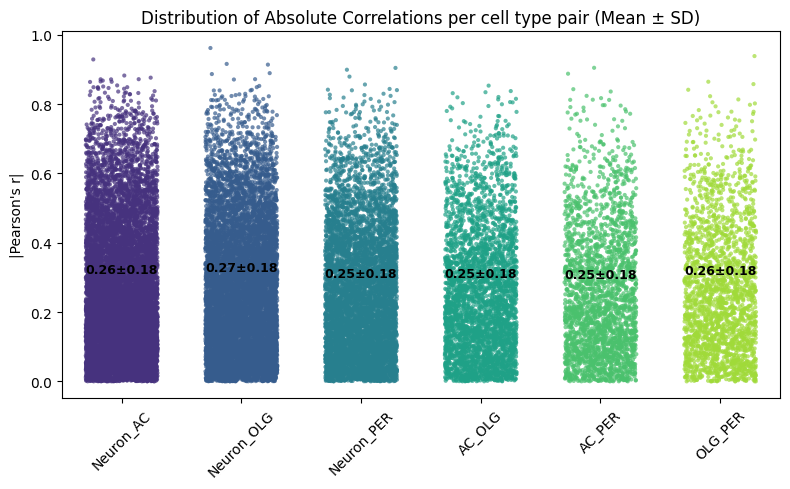

In [67]:
# Collect absolute correlation entries from each sheet
records = []
for sheet_name, df in master_corr_dict.items():
    abs_vals = df.abs().values.flatten()
    for val in abs_vals:
        records.append({'sheet': sheet_name, 'abs_corr': val})

all_corr_df = pd.DataFrame(records)

# Compute summary statistics
summary_df = (
    all_corr_df.groupby('sheet')['abs_corr']
    .agg(['mean', 'std'])
    .reset_index()
)
summary_df = (
    summary_df.set_index('sheet')
    .loc[[s for s in list(master_corr_dict.keys()) if s in summary_df['sheet'].values]]
    .reset_index()
)

# Plot individual dots
plt.figure(figsize=(8, 5))
sns.stripplot(
    data=all_corr_df,
    x='sheet',
    y='abs_corr',
    jitter=0.3,
    alpha=0.7,
    size=3,
    palette='viridis'
)

# Add mean ± SD labels above each group
for i, row in enumerate(summary_df.itertuples()):

    plt.text(
        i,
        row.mean + 0.05,  # vertical position
        f"{row.mean:.2f}±{row.std:.2f}",
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.xticks(rotation=45)
plt.ylabel("|Pearson's r|")
plt.xlabel('')
plt.title('Distribution of Absolute Correlations per cell type pair (Mean ± SD)')
plt.tight_layout()
plt.show()


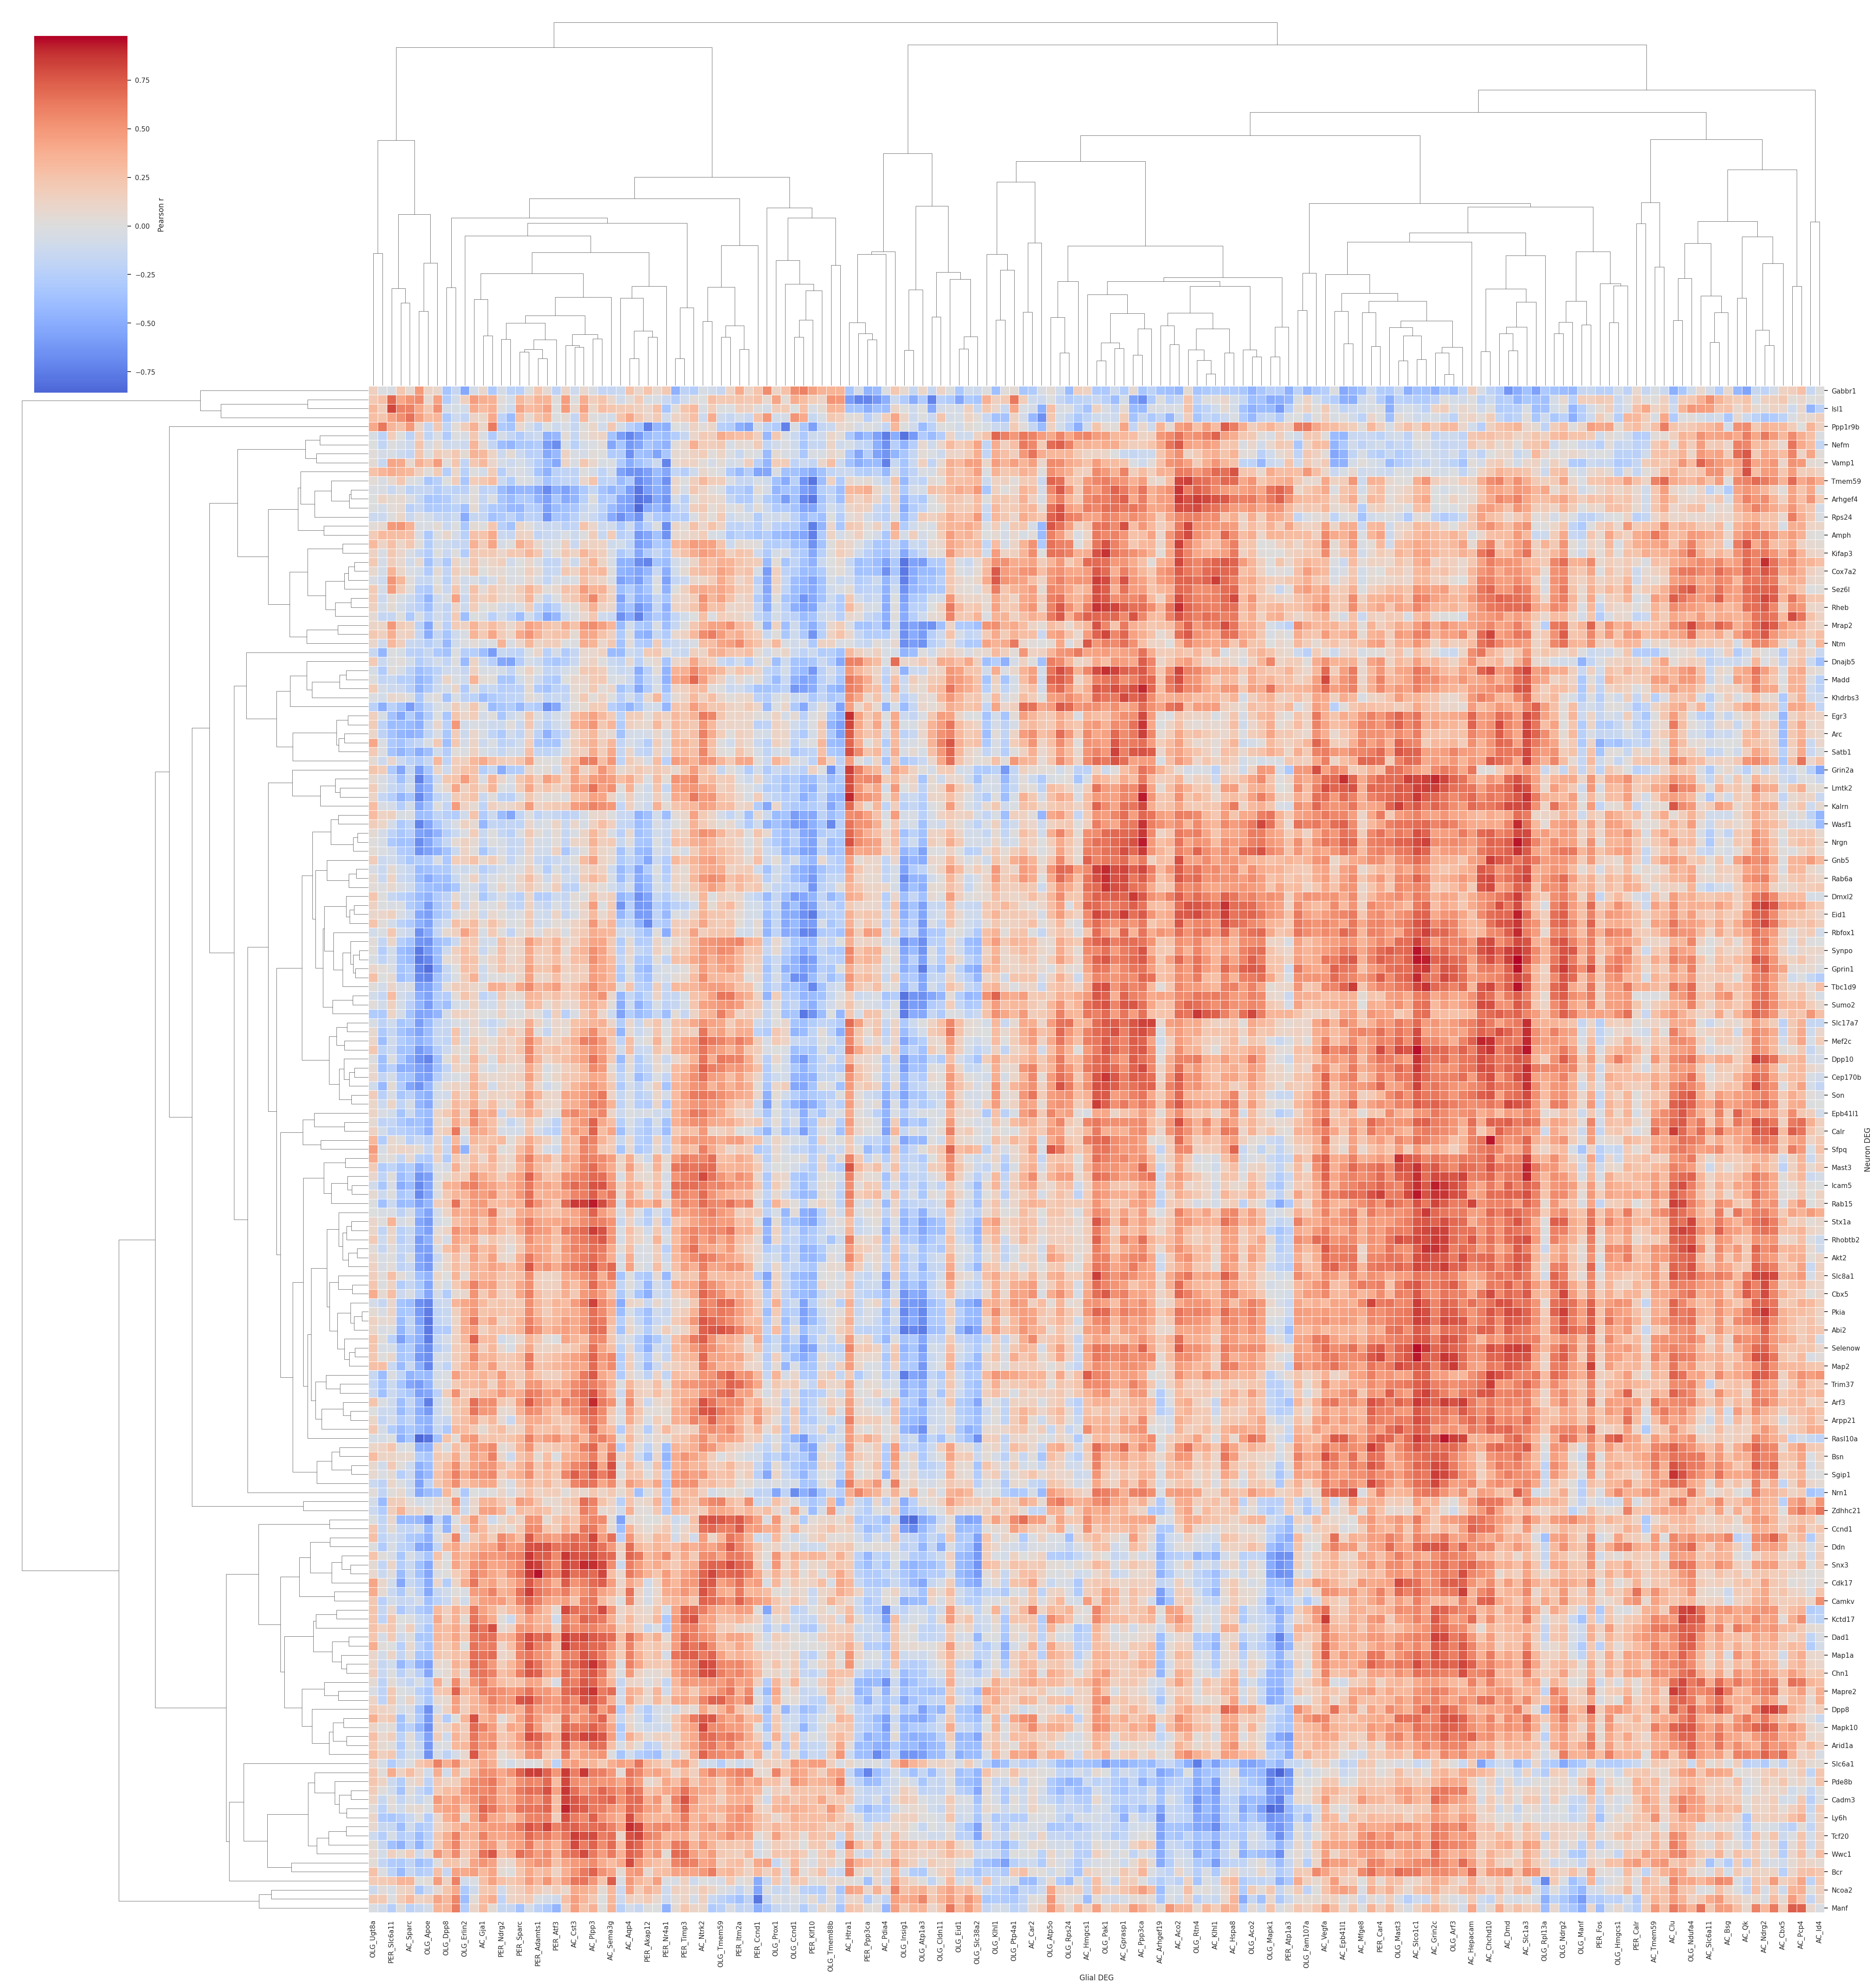

In [17]:
# Show neuron DEG vs glia DEG heatmap correlation
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list, optimal_leaf_ordering


row_dist   = pdist(integrated_df, metric=lambda u, v: 1 - np.corrcoef(u, v)[0, 1])
row_link   = linkage(row_dist, method="average")
row_link   = optimal_leaf_ordering(row_link, row_dist)
row_order  = leaves_list(row_link)

col_dist   = pdist(integrated_df.T, metric=lambda u, v: 1 - np.corrcoef(u, v)[0, 1])
col_link   = linkage(col_dist, method="average")
col_link   = optimal_leaf_ordering(col_link, col_dist)
col_order  = leaves_list(col_link)

corr_df_ord = integrated_df.iloc[row_order, :].iloc[:, col_order]

sns.set_theme(style="white")
g = sns.clustermap(
        integrated_df, 
        row_linkage=row_link,
        col_linkage=col_link,
        cmap="coolwarm", center=0,
        linewidths=.5, linecolor="white",
        figsize=(0.25*integrated_df.shape[1] + 3,
                 0.25*integrated_df.shape[0] + 3),
        cbar_kws=dict(label="Pearson r")
     )
g.ax_heatmap.set_xlabel("Glial DEG")
g.ax_heatmap.set_ylabel(f"Neuron DEG")
plt.show()

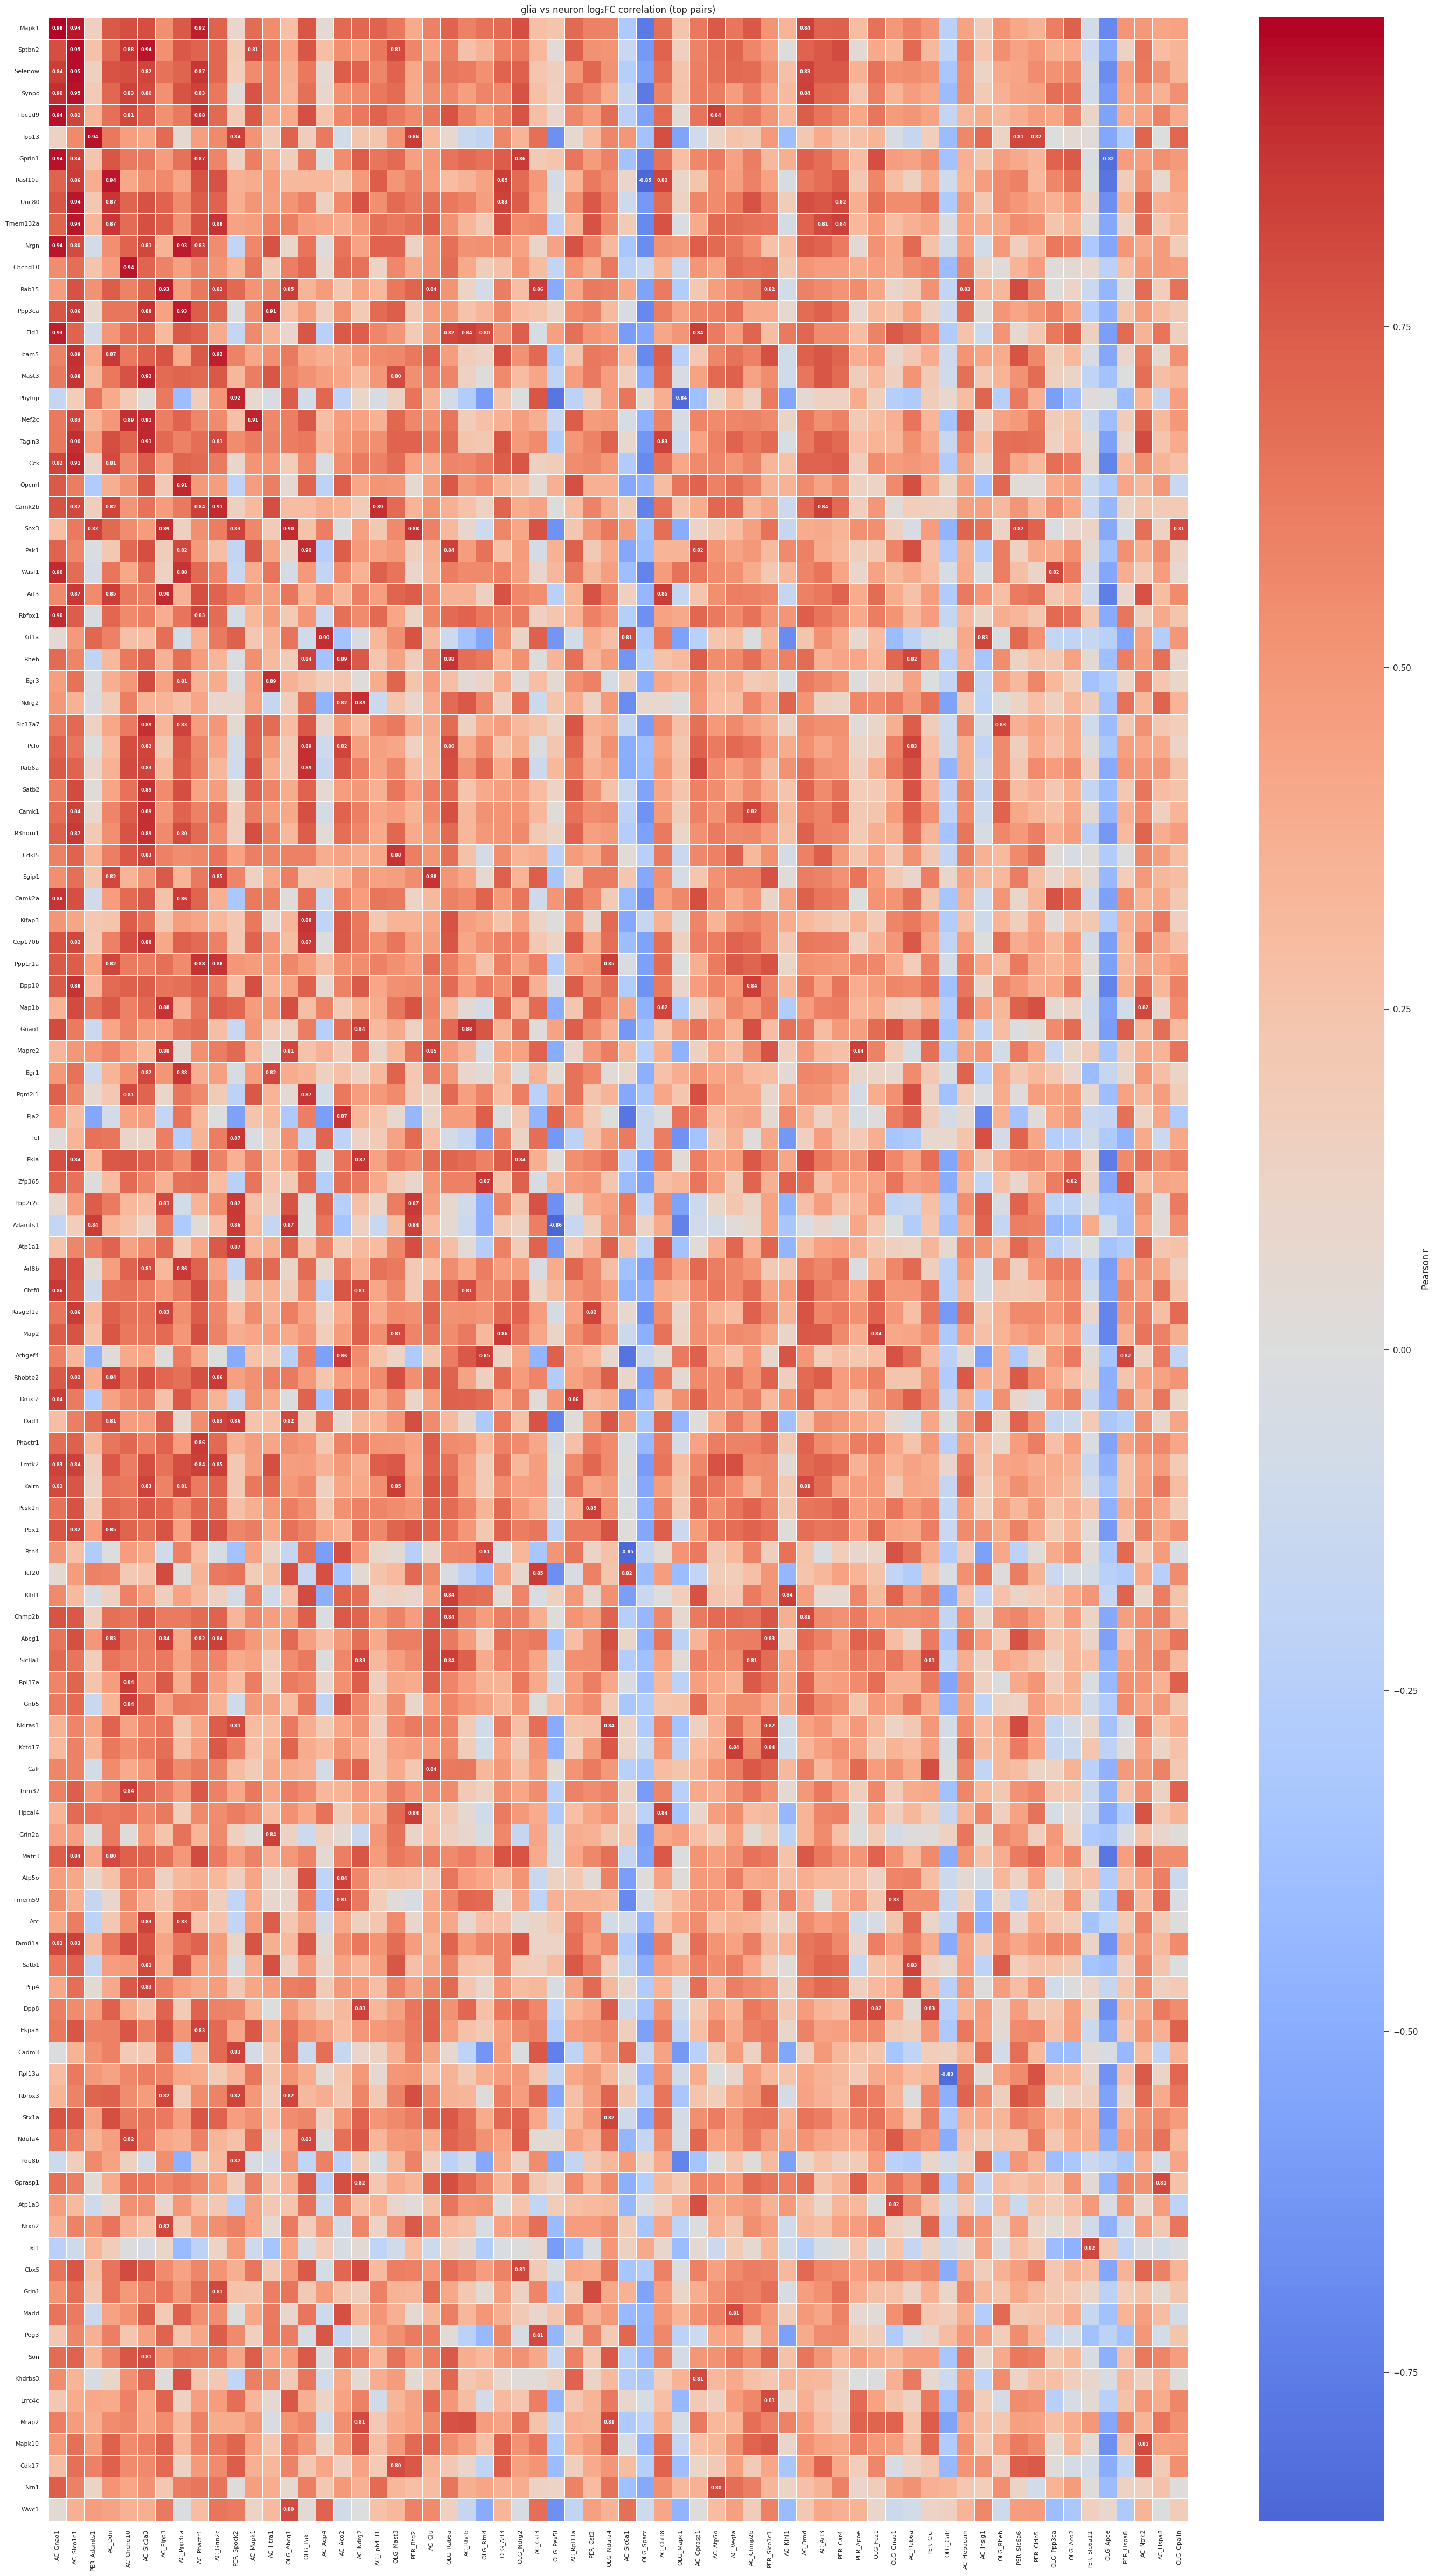

In [77]:
top_n = 300
flat = (
    integrated_df.stack()                
           .swaplevel()           
           .rename("r")
)
strong = flat.abs().sort_values(ascending=False).head(top_n).index
strong_pairs = flat.loc[strong]      # keep signed r values

sel_per = strong_pairs.index.get_level_values(0).unique()
sel_ac  = strong_pairs.index.get_level_values(1).unique()
sub_df  = integrated_df.loc[sel_ac, sel_per]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(0.4*sub_df.shape[1] + 2,
                                0.4*sub_df.shape[0] + 2))

sns.heatmap(sub_df, cmap="coolwarm", center=0,
            ax=ax, cbar_kws=dict(label="Pearson r"), linewidths=.5, linecolor="white")

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

for (per_gene, ac_gene), r in strong_pairs.items():
    i = sub_df.index.get_loc(ac_gene)
    j = sub_df.columns.get_loc(per_gene)
    ax.text(j + 0.5, i + 0.5, f"{r:.2f}",
            ha="center", va="center",
            fontsize=6, fontweight="bold", color="white")

plt.title(f"glia vs neuron log₂FC correlation (top pairs)")
plt.tight_layout()
plt.show()

In [18]:
ordered_neuron_deg = integrated_df.index[row_order].tolist()
ordered_glial_deg  = integrated_df.columns[col_order].tolist()

In [80]:
ordered_glial_deg_dict = {
    ct: [lbl.split("_", 1)[1] for lbl in ordered_glial_deg if lbl.startswith(f"{ct}_") ]
    for ct in ['AC', 'OLG', 'PER']
}  

In [ ]:
# Optional for NVU genes
deg_subset_dict = {
    'Neuron': [
        "Grin1", "Grin2a",      # NMDAR subunits – Ca2+-driven vasodilation
        "Camk1", "Camk2a", "Camk2b", "Ppp3ca",  # Ca2+/calmodulin effectors
        "Mapk1", "Rasgef1a",    # Ras–ERK signaling axis
        "Rgs4",                 # GPCR brake on cerebrovascular tone
        "Arc", "Egr1", "Egr3",  # Activity-induced IEGs with vascular targets
        "Rheb",                 # mTOR activator synchronizing anabolic demand
        "Atp1a1", "Atp1a3",     # Na+/K+-ATPase isoforms driving energy use
        "Slc17a7",              # Vesicular glutamate transporter → astrocytic signaling
        "Nrn1", "Sema7a",       # Secreted angiogenic / guidance cues
        "Cadm3", "Adamts1"      # Adhesion & ECM remodeling at the NVU
        ],
    'AC': ["Aqp4", "Slc1a3", "Vegfa", "Gja1", "Vcam1", "S1pr1", "Sparc", "Plpp3", "Car2", "Bsg", "Rasgef1a", "Htra1", "Cst3", "Apoe", "Id4"],
    'OLG': [],
    'PER': ["Slc2a1", "Apold1", "Timp3", "Tnfrsf12a", "Akap12", "Adamts1", "Spock2", "Cldn5", "Car4", "Slco1c1", "Bsg", "Nr4a1", "Sema3g"],
}

In [20]:
# Optional for NVU genes
ordered_glial_deg_dict = {
    ct: [lbl.split("_", 1)[1] for lbl in ordered_glial_deg if lbl.startswith(f"{ct}_") and lbl.split("_", 1)[1] in deg_subset_dict[ct]]
    for ct in ['AC', 'OLG', 'PER']
}
ordered_neuron_deg = [lbl for lbl in ordered_neuron_deg if lbl in deg_subset_dict['Neuron']]

In [21]:
master_corr_dict = {}

for i,ct1 in enumerate(ct_list):
    for j,ct2 in enumerate(ct_list):

        if i >= j:
            continue

        current_ct = f"{ct1}_{ct2}"

        if ct1 == 'Neuron':
            ct1_df = neuron_df
            ct1_deg_list = ordered_neuron_deg
        else:
            ct1_df = ct_dict[ct1]
            ct1_deg_list = ordered_glial_deg_dict[ct1]

        ct2_df = ct_dict[ct2]
        ct2_deg_list = ordered_glial_deg_dict[ct2]

        X = ct1_df[ct1_deg_list].to_numpy(dtype=float)       # shape (regions, m)
        Y = ct2_df[ct2_deg_list].to_numpy(dtype=float)     # shape (regions, n)

        # centre each column (zero mean) and normalise to unit variance
        Xc = (X - X.mean(0)) / X.std(0, ddof=0)
        Yc = (Y - Y.mean(0)) / Y.std(0, ddof=0)

        # correlation = (Xcᵀ · Yc) / (N‑1)   because each col is z‑scored
        N = X.shape[0]
        corr_mat = (Xc.T @ Yc) / (N - 1)                # shape (m, n)

        corr_df = pd.DataFrame(corr_mat, index=ct1_deg_list, columns=ct2_deg_list)

        master_corr_dict[current_ct] = corr_df
        print(f"{current_ct} done")


Neuron_AC done
Neuron_OLG done
Neuron_PER done
AC_OLG done
AC_PER done
OLG_PER done


In [23]:
from scipy.stats import t

master_corr_dict = {}

for i,ct1 in enumerate(ct_list):
    for j,ct2 in enumerate(ct_list):

        if i >= j:
            continue

        current_ct = f"{ct1}_{ct2}"

        if ct1 == 'Neuron':
            ct1_df = neuron_df
            ct1_deg_list = ordered_neuron_deg
        else:
            ct1_df = ct_dict[ct1]
            ct1_deg_list = ordered_glial_deg_dict[ct1]

        ct2_df = ct_dict[ct2]
        ct2_deg_list = ordered_glial_deg_dict[ct2]


        X = ct1_df[ct1_deg_list].to_numpy(dtype=float)       # shape (regions, m)
        Y = ct2_df[ct2_deg_list].to_numpy(dtype=float)     # shape (regions, n)

        # centre each column (zero mean) and normalise to unit variance
        Xc = (X - X.mean(0)) / X.std(0, ddof=0)
        Yc = (Y - Y.mean(0)) / Y.std(0, ddof=0)

        # correlation = (Xcᵀ · Yc) / (N‑1)   because each col is z‑scored
        N = X.shape[0]
        corr_mat = (Xc.T @ Yc) / (N - 1)   

        # compute two‑tailed p‑values via the t‑statistic
        dof     = N - 2

        # avoid division by zero
        eps     = 1e-16
        r_abs   = np.abs(corr_mat)
        t_stat  = corr_mat * np.sqrt(dof / np.maximum(1 - corr_mat**2, eps))
        p_mat   = 2 * (1 - t.cdf(r_abs * np.sqrt(dof / np.maximum(1 - corr_mat**2, eps)), dof))

        p_df = pd.DataFrame(p_mat, index=ct1_deg_list, columns=ct2_deg_list)

        # store both in master dict
        master_corr_dict[current_ct] = {
            "r" : pd.DataFrame(corr_mat, index=ct1_deg_list, columns=ct2_deg_list),
            "p" : p_df
        }

        print(f"{current_ct} done: shape={corr_mat.shape}, N={N}, dof={dof}")


Neuron_AC done: shape=(20, 15), N=18, dof=16
Neuron_OLG done: shape=(20, 0), N=18, dof=16
Neuron_PER done: shape=(20, 13), N=18, dof=16
AC_OLG done: shape=(15, 0), N=18, dof=16
AC_PER done: shape=(15, 13), N=18, dof=16
OLG_PER done: shape=(0, 13), N=18, dof=16


### 3.3 Chord diagram setup

In [38]:
deg_count = {}
for ct in ct_list:
    if ct == 'Neuron':
        deg_count[ct] = len(neuron_deg_list)
    else:
        deg_list_temp = glial_DEG_dict[ct]
        deg_count[ct] = len(deg_list_temp)

deg_count

{'Neuron': 169, 'AC': 64, 'OLG': 56, 'PER': 39}

In [ ]:
# Optional for NVU genes
deg_count = {}
for ct in ct_list:
    if ct == 'Neuron':
        deg_count[ct] = len(ordered_neuron_deg)
    else:
        deg_list_temp = ordered_glial_deg_dict[ct]
        deg_count[ct] = len(deg_list_temp)

deg_count

In [25]:
interval_dict = {}
for ct in ct_list:
    if deg_count[ct] == 0:
        interval_dict[ct] = 0
        continue
    interval_temp = (deg_count[ct] - 1) / deg_count[ct]
    interval_dict[ct] = interval_temp
print(interval_dict)

{'Neuron': 0.95, 'AC': 0.9333333333333333, 'OLG': 0, 'PER': 0.9230769230769231}


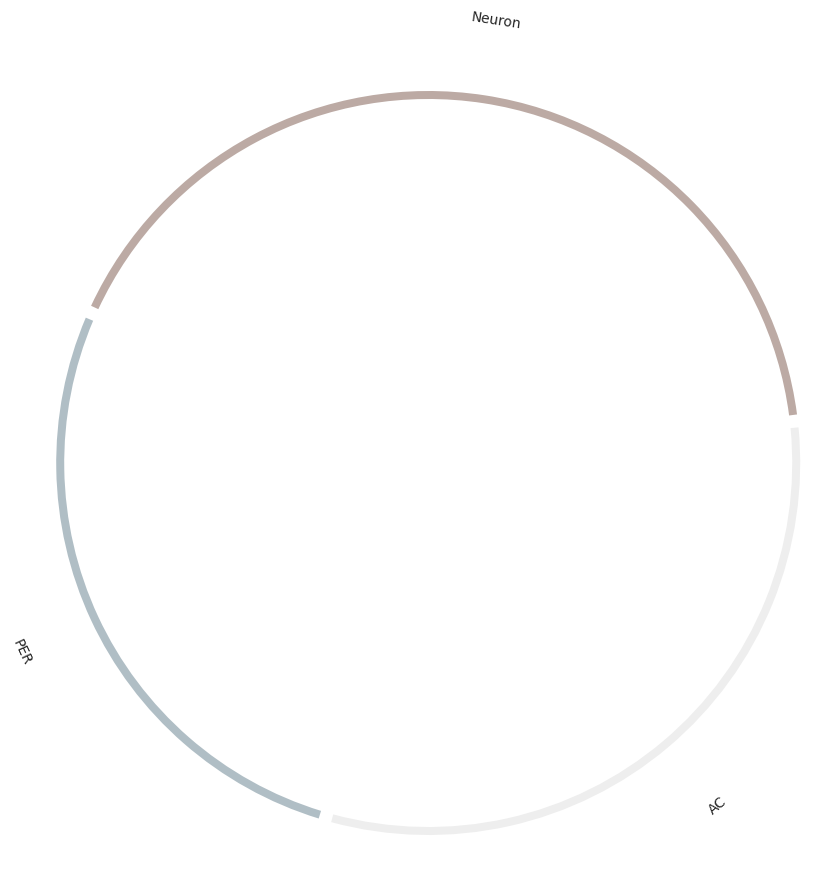

In [68]:
circle = Gcircle(figsize=(8,8)) 
for name in ['Neuron','AC','OLG','PER']:
        if deg_count[name] == 0:
            continue
        # line   = line.rstrip().split(",") 
        length = int(deg_count[name]) 
        arc    = Garc(arc_id=name, size=length, interspace=2, raxis_range=(910,930), labelposition=200,linewidth=0, label_visible=True)
        circle.add_garc(arc) 
circle.set_garcs(-65,295) 

### 3.4 Label genes

In [28]:
genes_to_label = {
    'Neuron': [],
    'AC': [],
    'OLG': [],
    'PER': []
}
chord_dict = collections.defaultdict(list)
for i, ct1 in enumerate(ct_list):
    for j, ct2 in enumerate(ct_list):
        if i >= j:
            continue
        current_ct = f"{ct1}_{ct2}"
        if current_ct not in master_corr_dict:
            continue
        corr_df = master_corr_dict[current_ct]['r']
        p_df = master_corr_dict[current_ct]['p']
        ct1_interval = interval_dict[ct1]
        ct2_interval = interval_dict[ct2]

        count_temp =0
        for m, g_ct1 in enumerate(corr_df.index.to_list()):
            for n, g_ct2 in enumerate(corr_df.columns.to_list()):
                corr_temp = corr_df.loc[g_ct1, g_ct2]
                p_temp = p_df.loc[g_ct1, g_ct2]
                if abs(corr_temp) > 0.8 and p_temp < 0.05:
                # if abs(corr_temp) > 0.6 and p_temp < 0.05:    # Optional for NVU genes
                    count_temp += 1
                    chord_dict[f'{current_ct}_{g_ct1}_{g_ct2}'].append((ct1, m*ct1_interval, (m+1)*ct1_interval, 905))
                    chord_dict[f'{current_ct}_{g_ct1}_{g_ct2}'].append((ct2, n*ct2_interval, (n+1)*ct2_interval, 905))
                    chord_dict[f'{current_ct}_{g_ct1}_{g_ct2}'].append(abs(corr_temp))
                    if abs(corr_temp) > 0.9 and g_ct1!= g_ct2:
                        genes_to_label[ct1].append(g_ct1)
                        genes_to_label[ct2].append(g_ct2)
        print(f"{current_ct} done: {count_temp} strong correlations found")

Neuron_AC done: 55 strong correlations found
Neuron_OLG done: 0 strong correlations found
Neuron_PER done: 22 strong correlations found
AC_OLG done: 0 strong correlations found
AC_PER done: 15 strong correlations found
OLG_PER done: 0 strong correlations found


In [270]:
# remove duplicates for each list
for ct in genes_to_label:
    genes_to_label[ct] = list(set(genes_to_label[ct]))
    print(f"{ct} genes to label: {len(genes_to_label[ct])}")

Neuron genes to label: 25
AC genes to label: 10
OLG genes to label: 2
PER genes to label: 3


In [233]:
# All DEGs
genes_to_label = {
    'Neuron': [
    'Mast3', 'Rasl10a', 'Nrgn', 'Snx3', 'Ipo13', 'Ppp3ca', 'Kcnf1', 'Synpo',
    'Mapk1', 'Tagln3', 'Opcml', 'Phyhip', 'Unc80', 'Arf3', 'Camk2b', 'Sptbn2',
    'Icam5', 'Cck', 'Eid1', 'Slc2a3', 'Gprin1', 'Tmem132a', 'Rab15', 'Ssr3',
    'Wasf1', 'Mef2c','Nub1','Egr3','Arc'
],
    'AC': [
        'Ndrg2', 'Aqp4', 'Phactr1', 'Slco1c1', 'Plpp3', 'Slc1a3', 
        'Htra1', 'Grin2c', 'Clu', 'Epb41l1'
    ],
    'OLG': [
        'Mast3', 'Pak1', 'Rab6a', 'Abcg1', 'Cst3'
    ],
    'PER': [
        'Car4', 'Sparc', 'Spock2', 'Timp3', 'Adamts1', 'Clu'
    ]
}


In [ ]:
# Optional for NVU genes
genes_to_label = deg_subset_dict

In [30]:
order_dict ={
    'Neuron':ordered_neuron_deg,
    'AC': ordered_glial_deg_dict['AC'],
    'OLG': ordered_glial_deg_dict['OLG'],
    'PER': ordered_glial_deg_dict['PER']
}

In [69]:
for ct in genes_to_label:
    for gene in genes_to_label[ct]:
        if gene in order_dict[ct]:
            circle.tickplot(
                ct,
                raxis_range=(935, 955),  # outer radius
                tickpositions=[order_dict[ct].index(gene)],
                # tickinterval=None,         
                tickwidth=0.5,          # width of the tick lines
                ticklabels=[gene],  
                ticklabelmargin=15,
                ticklabelsize = 14,
                ticklabelorientation ='vertical',
                )



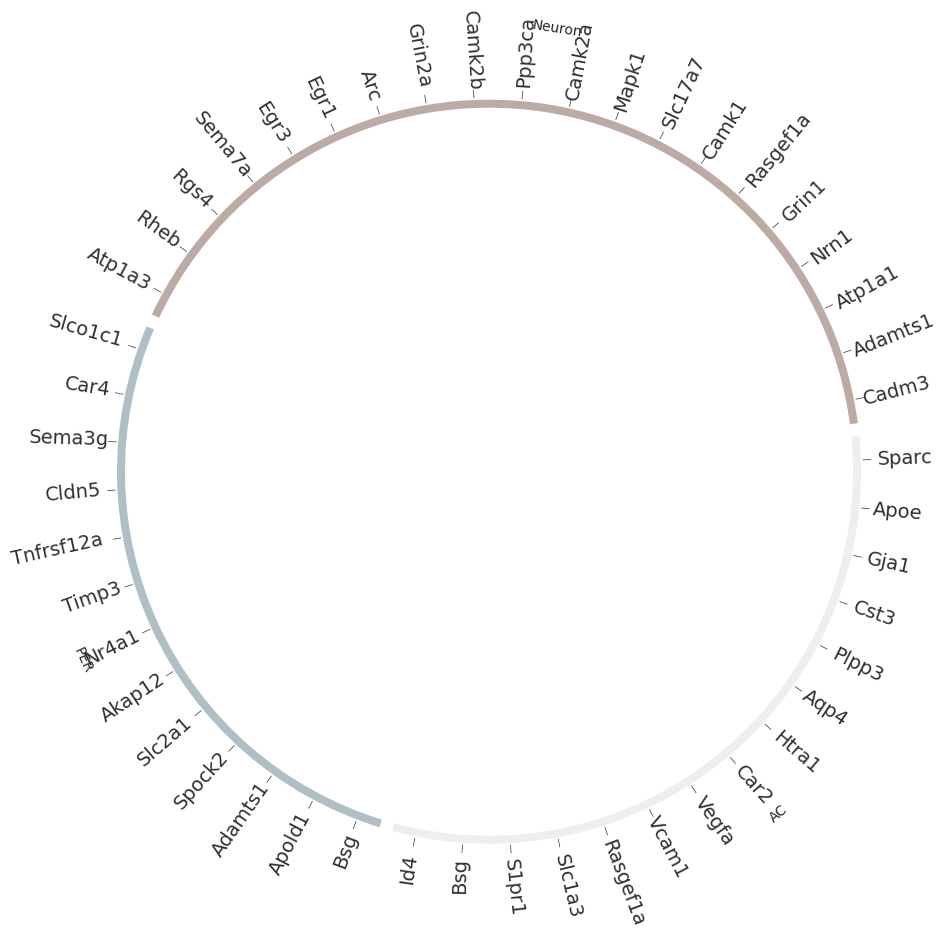

In [70]:
circle.figure

### 3.5 Plot chord

In [46]:
cmap = mpl.cm.YlGnBu 
norm = mpl.colors.Normalize(vmin=0.8, vmax=1)
# norm = mpl.colors.Normalize(vmin=0.6, vmax=1) # Optional for NVU genes
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

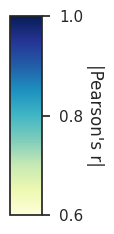

In [51]:
fig, ax = plt.subplots(figsize=(1.3, 2.5))
cbar = fig.colorbar(sm, cax=ax, orientation='vertical')

cbar.set_ticks([ 0.8, 0.9, 1.0])
cbar.set_ticklabels([ '0.8', '0.9', '1.0'])

# cbar.set_ticks([ 0.6, 0.8, 1.0])
# cbar.set_ticklabels([ '0.6', '0.8', '1.0'])   # Optional for NVU genes

cbar.set_label("|Pearson's r|", rotation=270, labelpad=15, fontsize=12)

plt.tight_layout()
plt.show()

In [63]:
# sort the chord_dict by the correlation value
chord_list = []
for key, entries in chord_dict.items():
    chord_list.append([key, entries])
chord_list.sort(key=lambda x: x[1][2], reverse=False)

In [71]:
for chord in chord_list:
    circle.chord_plot(chord[1][0], chord[1][1], facecolor=sm.to_rgba(chord[1][2]))

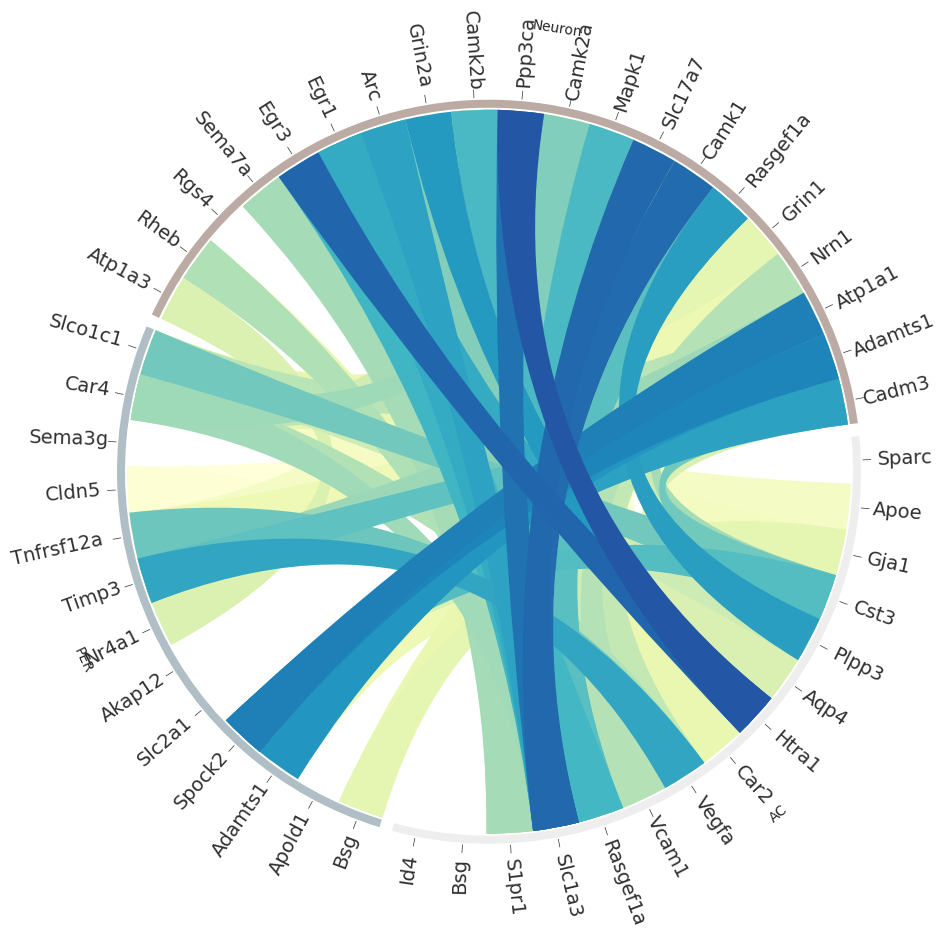

In [72]:
circle.figure

In [50]:
arcdata_dict = collections.defaultdict(dict)
color_dict   = {"Neuron":"#5ec05e", "AC":"#dbdb8d", "OLG":"#9edae5", "PER":"#c49c94"}
f = []
for name in ['Neuron','AC','OLG','PER']:
    if name not in arcdata_dict:
        arcdata_dict[name]["positions"] = []
        arcdata_dict[name]["widths"]    = [] 
        arcdata_dict[name]["colors"]    = [] 
    for i in range(deg_count[name]):
            arcdata_dict[name]["positions"].append(i) 
            arcdata_dict[name]["widths"].append(1)
            arcdata_dict[name]["colors"].append(color_dict[name])

In [73]:
for key in arcdata_dict:
    if arcdata_dict[key]["positions"] == []:
        continue
    circle.barplot(key, data=[1]*len(arcdata_dict[key]["positions"]), positions=arcdata_dict[key]["positions"], 
                   width=arcdata_dict[key]["widths"], raxis_range=[905,935],linewidth=0.2,edgecolor="#ffffff", facecolor=arcdata_dict[key]["colors"])    

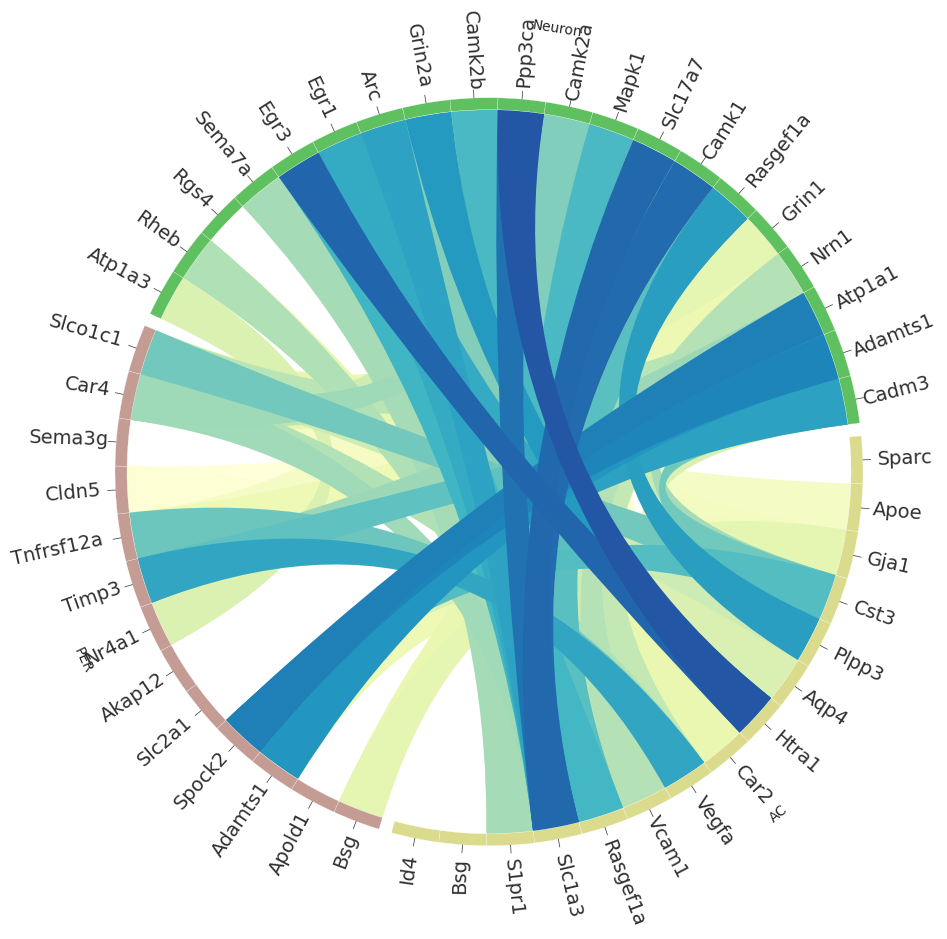

In [74]:
circle.figure

In [281]:
circle.figure.savefig(os.path.join(fig_path,"circos_plot_n3_nl.pdf"),
                      format='pdf',
                      dpi=600,
                      bbox_inches='tight',)

In [ ]:
# Options for NVU genes
circle.figure.savefig(os.path.join(fig_path,"circos_plot_nvu.pdf"),
                      format='pdf',
                      dpi=600,
                      bbox_inches='tight',)

## 4. Gene-gene co-variation scatter plot

In [107]:
fig_path = '/stanley/WangLab/Data/Analyzed/2024-12-02-Mingrui-SCZ/figures/manuscript figure/spatial/regression'
if not os.path.exists(fig_path):
    os.mkdir(fig_path)

In [108]:
sc.set_figure_params(dpi_save=300)
sc.settings.figdir = fig_path

In [58]:
# read excel file
ct_dict = pd.read_excel(f"{out_path}/glia_log2FC_by_region_RIBO.xlsx", sheet_name=None, index_col=0)
neuron_df = pd.read_excel(f"{out_path}/neuron_log2FC_by_region_RIBO.xlsx", sheet_name='Neuron', index_col=0)

In [ ]:
color_map ={
    'SSC': '#2AB529',
    'PFC': '#F6C34C',
    'ST': '#00C1FD',
    'TH': '#f78a88',
    'HP': '#8B09BE',
    'Other': '#cccccc'
}

In [ ]:
rgn_dict = {'PFC': ['CTX_mPFC5', 'CTX_ILA2/3'],
            'SSC': ['CTX_L2/3','CTX_L4','CTX_L5','CTX_L6'],
            'ST': ['STR'],
            'HP': ['CTX_CA1', 'CTX_CA3', 'CTX_DG', 'CTX_HIP'],
            'TH': ['TH_1', 'TH_2', 'TH_EPI','TH_RT']
            }

In [ ]:
region_colors = {}
for rgn_group, rgn_list in rgn_dict.items():
    for rgn in rgn_list:
        region_colors[rgn] = color_map[rgn_group]
for rgn in adata.obs['region_label'].unique():
    if rgn not in region_colors:
        region_colors[rgn] = color_map['Other']

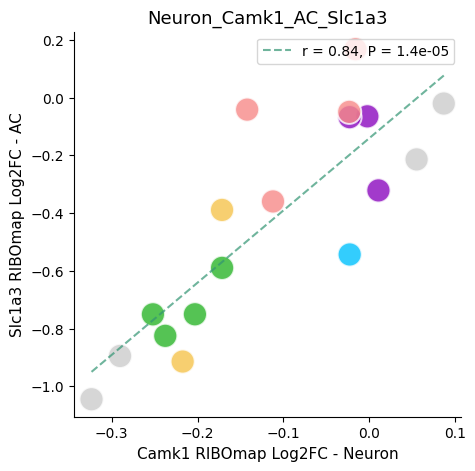

In [78]:
ct1 = 'Neuron'
ct2 = 'AC'
gene1 = 'Camk1'
gene2 = 'Slc1a3' 

if ct1 == 'Neuron':
    x = neuron_df[gene1]
else:
    x = ct_dict[ct1][gene1]
y = ct_dict[ct2][gene2]

df = pd.merge(x, y, on='region_label', how="inner")

plt.figure(figsize=(5, 5))
ax = sns.scatterplot(
    data=df,
    x=gene1,
    y=gene2,
    hue='region_label',
    palette=region_colors,
    s=300,
    alpha=0.8,
    legend = False
)


slope, intercept, r, pval, *_ = linregress(df[gene1], df[gene2])
x_vals = [df[gene1].min(), df[gene1].max()]
x_vals
y_vals = [slope * x + intercept for x in x_vals]

ax.plot(x_vals, y_vals, linestyle='--', color='#329573',
            label=f"r = {r:.2f}, P = {pval:.2g}", alpha=0.7)


ax.set_title(f"{ct1}_{gene1}_{ct2}_{gene2}", fontsize=13)
ax.set_xlabel(f"{gene1} RIBOmap Log2FC - {ct1}", fontsize=11)
ax.set_ylabel(f"{gene2} RIBOmap Log2FC - {ct2}", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper right')
plt.savefig(os.path.join(fig_path,'gene corr',f'{ct1}_{gene1}_{ct2}_{gene2}.pdf'), format='pdf', dpi=300)
plt.show()


## 5. Activity-gene co-variation

### 5.1 Calculate IEG score as activity indicator

In [ ]:
IEG_list = [
    "Arc", "Atf3", "Bdnf", "Btg2", "Dusp1","Ier2",
    "Klf4","Dusp5","Dusp6",
    "Ptgs2", "Homer1", "Fosl2",
    "Egr1", "Egr2", "Egr3", "Egr4",
    "Fos", "Fosb", "Gadd45g", "Junb", "Jun",
    "Npas4",
    "Nr4a1", "Nr4a2", "Nr4a3",
    "Nrn1", "Rgs2",
]

In [ ]:
adata.X = adata.layers['log2_norm1e4_scaled'].copy()
sc.tl.score_genes(adata, gene_list=IEG_list, score_name='IEG_score')

In [ ]:
protocol   = "RIBO"
obs_metric = "IEG_score"
genes      = adata.var_names            # ← or pass your own list

data_dict = {}

for rgn in adata.obs["region_label"].unique():
    if rgn in region_to_exclude:
        continue

    ad_neu = adata[(adata.obs["spatial_analysis"])
                   & (adata.obs["region_label"] == rgn)
                   & (adata.obs["protocol"] == protocol)]

    ad_ac  = adata[(adata.obs["level_2"] == "AC")
                   & (adata.obs["region_label"] == rgn)
                   & (adata.obs["protocol"] == protocol)]

    if ad_neu.n_obs == 0 or ad_ac.n_obs == 0:
        continue

    neu_wt  = ad_neu[ad_neu.obs["condition"] == "WT"].obs[obs_metric].mean()
    neu_het = ad_neu[ad_neu.obs["condition"] == "HET"].obs[obs_metric].mean()
    region_row = {f"neuron_{obs_metric}": neu_het - neu_wt}

    for gene in genes:
        wt_mat  = ad_ac[ad_ac.obs["condition"] == "WT"].layers["log2_norm1e4"][
                      :, adata.var_names == gene
                  ]
        het_mat = ad_ac[ad_ac.obs["condition"] == "HET"].layers["log2_norm1e4"][
                      :, adata.var_names == gene
                  ]

        region_row[gene] = het_mat.mean() - wt_mat.mean()

    data_dict[rgn] = region_row

logfc_df = (
    pd.DataFrame.from_dict(data_dict, orient="index")
      .rename_axis("region_label")
      .sort_index()
)

logfc_df.head()        # preview


### 5.2 Plot heatmap

In [ ]:
logfc_df = logfc_df.sort_values(by='neuron_IEG_score', ascending=True)

In [ ]:
value_dict = {}
for current_gene in adata.var_names:
    if current_gene not in logfc_df.columns:
        continue

    rho, pval = spearmanr(logfc_df['neuron_IEG_score'], logfc_df[current_gene])
    slope, intercept, *_ = linregress(logfc_df['neuron_IEG_score'], logfc_df[current_gene])
    value_dict[current_gene] = (rho, pval, slope, intercept)

coor_df = pd.DataFrame(value_dict).T
coor_df.columns = ['rho', 'pval', 'slope', 'intercept']

expr_mean_data = adata[ (adata.obs['protocol'] == protocol)&(adata.obs['level_2'] == 'AC'), coor_df.index]
expr_mean = pd.DataFrame(expr_mean_data.layers['log2_norm1e4'].toarray().copy(), index=expr_mean_data.obs_names, columns=expr_mean_data.var_names)
expr_mean['region_label'] = expr_mean_data.obs['region_label']
expr_mean = expr_mean.groupby('region_label').mean()
coor_df['expr_mean'] = expr_mean.max(axis=0)

coor_df = coor_df.loc[coor_df['pval'] < 0.05, :]
coor_df = coor_df.loc[coor_df['expr_mean'] > 0.4, :]
coor_df = coor_df.sort_values(by='rho', ascending=True)

In [ ]:
AC_gene_list = glial_DEG_dict['AC']

In [ ]:
coor_df = coor_df[coor_df.index.isin(AC_gene_list)]
basal_df = logfc_df.loc[:, ['neuron_IEG_score']].T
plot_df = logfc_df.loc[:, coor_df.index.tolist()].T

In [ ]:
genes_to_label = [gene for gene in plot_df.index if gene in AC_gene_list]
genes_index = [plot_df.index.get_loc(gene) + 0.5 for gene in genes_to_label]

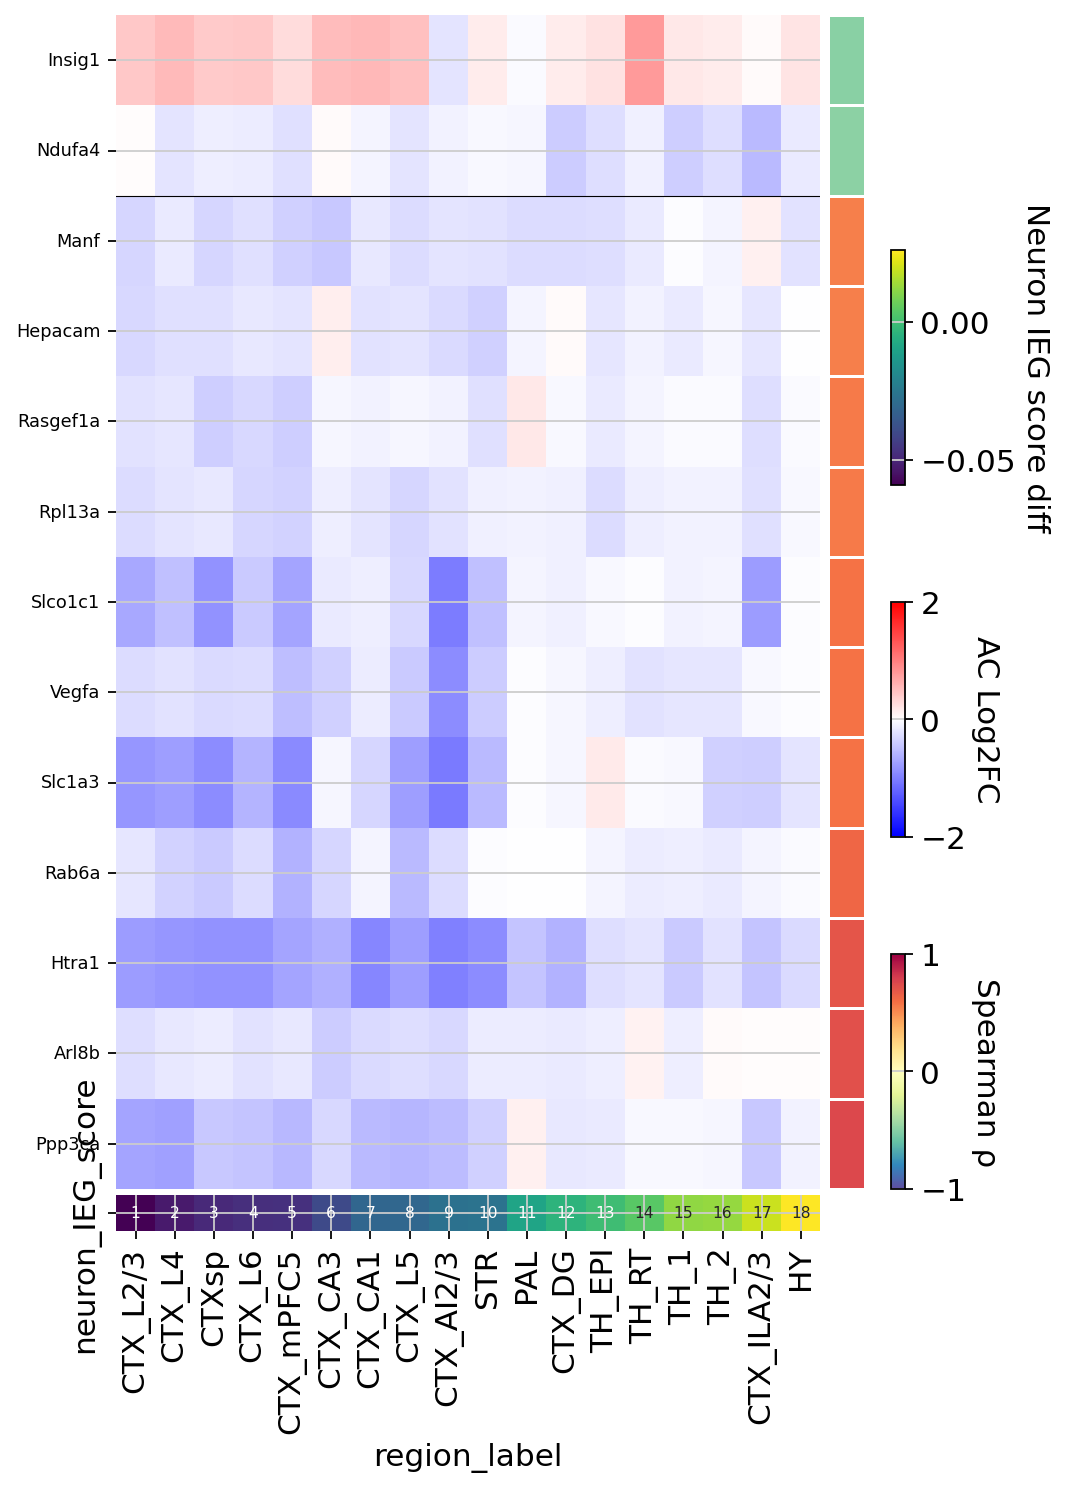

In [ ]:
# Figure & axes
fig = plt.figure(figsize=(6, 10))      
gs  = GridSpec(
        nrows=2, ncols=2,
        height_ratios=[.97, .03],       
        width_ratios =[.95, .05],
        hspace=0.01, wspace=0.02)

ax_main = fig.add_subplot(gs[0, 0])    
ax_rho = fig.add_subplot(gs[0, 1])    
ax_basal = fig.add_subplot(gs[1, 0]) 

fig.add_subplot(gs[1, 1]).axis('off')
    
# Expression heat-map
sns.heatmap(plot_df, cmap='bwr', vmin=-2, vmax=2, ax=ax_main, cbar=False,
                 cbar_kws={'label': 'Log2FC', 'shrink': 0.25, 'location': 'right'})

ax_main.set_xticks([])               
ax_main.set_xlabel('')
ax_main.set_yticks(genes_index)
ax_main.set_yticklabels(genes_to_label, rotation=0, fontsize=8)

# Add horizontal line
current_pos = coor_df.loc[coor_df['rho'] < 0, :].shape[0]
ax_main.axhline(y=current_pos, color='black', linewidth=.5, alpha=1)


# Rho heat-map
sns.heatmap(coor_df.loc[:, ['rho']], cmap='Spectral_r', vmin=-1, vmax=1, 
                  cbar=False, linewidth=.5, linecolor='white',
                  ax=ax_rho)
# Remove y-axis ticks for the second plot
ax_rho.set_yticks([])
ax_rho.set_yticklabels([])
ax_rho.set_xticks([])
ax_rho.set_xticklabels([])

# Basal expression
annot_data = [range(1, basal_df.shape[1] + 1)]
sns.heatmap(
    basal_df,
    cmap='viridis',            
    cbar=False,
    annot=annot_data,
    fmt='d',
    annot_kws={"size": 7},
    ax=ax_basal)

# Add colorbars for both subplots with proper positioning to avoid overlap
cax = ax_main.inset_axes([1.1, .6, 0.02, 0.2])
cbar1 = plt.colorbar(ax_basal.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar1.set_label('Neuron IEG score diff', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.1, .3, 0.02, 0.2])
cbar2 = plt.colorbar(ax_main.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar2.set_label('AC Log2FC', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.1, 0, 0.02, 0.2])
cbar3 = plt.colorbar(ax_rho.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar3.set_label('Spearman ρ', rotation=270, labelpad=15)

plt.savefig(os.path.join(fig_path, 'AD AC DEG.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
protocol   = "RIBO"
obs_metric = "IEG_score"
genes      = adata.var_names            # ← or pass your own list

data_dict = {}

for rgn in adata.obs["region_label"].unique():
    if rgn in region_to_exclude:
        continue

    ad_neu = adata[(adata.obs["spatial_analysis"])
                   & (adata.obs["region_label"] == rgn)
                   & (adata.obs["protocol"] == protocol)]

    ad_olg  = adata[(adata.obs["level_2"] == "OLG")
                   & (adata.obs["region_label"] == rgn)
                   & (adata.obs["protocol"] == protocol)]

    if ad_neu.n_obs == 0 or ad_olg.n_obs == 0:
        continue

    neu_wt  = ad_neu[ad_neu.obs["condition"] == "WT"].obs[obs_metric].mean()
    neu_het = ad_neu[ad_neu.obs["condition"] == "HET"].obs[obs_metric].mean()
    region_row = {f"neuron_{obs_metric}": neu_het - neu_wt}

    for gene in genes:
        wt_mat  = ad_olg[ad_olg.obs["condition"] == "WT"].layers["log2_norm1e4"][
                      :, adata.var_names == gene
                  ]
        het_mat = ad_olg[ad_olg.obs["condition"] == "HET"].layers["log2_norm1e4"][
                      :, adata.var_names == gene
                  ]


        region_row[gene] = het_mat.mean() - wt_mat.mean()

    data_dict[rgn] = region_row

logfc_df_olg = (
    pd.DataFrame.from_dict(data_dict, orient="index")
      .rename_axis("region_label")
      .sort_index()
)

logfc_df_olg.head()

,neuron_IEG_score,A2m,A4galt,Aacs,Aak1,Abca5,Abcb1a,Abcb9,Abcc9,Abcf3,...,Zmiz1,Zmym1,Zmym3,Zmynd10,Znfx1,Znrf1,Zswim6,Zswim8,Zxdb,Zyg11b
region_label,,,,,,,,,,,,,,,,,,,,,
CTX_AI2/3,-0.027286,-0.081742,0.132307,0.143562,-0.235803,0.000000,0.269675,-0.182762,0.000000,0.218103,...,0.031441,0.000000,0.161939,0.068823,-0.179765,0.198108,-0.187493,0.048490,-0.108146,-0.129740
CTX_CA1,-0.031420,-0.156685,-0.093331,0.079811,-0.202286,-0.071667,-0.165483,0.037592,0.000000,0.073794,...,0.281738,0.047049,0.138609,-0.257169,0.075509,0.097499,0.015354,0.233548,-0.417039,-0.255116
CTX_CA3,-0.039956,-0.363215,0.118473,-0.045850,-0.714906,0.000000,0.000000,0.399812,-0.112794,-0.055461,...,-0.241333,0.208285,-0.198495,0.194524,0.134726,-0.121147,0.166789,0.134721,0.000000,0.000000
CTX_DG,-0.003875,0.027530,0.000000,0.287785,0.138613,0.000000,-0.085993,-0.162132,0.000000,0.295720,...,-0.308024,-0.072840,0.062802,-0.118871,-0.057761,-0.020991,0.199104,-0.022550,-0.039776,0.000000
CTX_ILA2/3,0.019311,0.000000,0.000000,0.000000,0.650463,0.217360,0.000000,0.000000,0.000000,0.271181,...,-0.148488,0.000000,-0.863592,0.000000,-0.238950,0.000000,-0.165891,-0.138693,-0.323284,0.000000


In [ ]:
logfc_df_olg=logfc_df_olg.sort_values(by='neuron_IEG_score', ascending=True)

In [ ]:
value_dict = {}
for current_gene in adata.var_names:
    if current_gene not in logfc_df_olg.columns:
        continue

    rho, pval = spearmanr(logfc_df_olg['neuron_IEG_score'], logfc_df_olg[current_gene])
    slope, intercept, *_ = linregress(logfc_df_olg['neuron_IEG_score'], logfc_df_olg[current_gene])
    value_dict[current_gene] = (rho, pval, slope, intercept)

coor_df = pd.DataFrame(value_dict).T
coor_df.columns = ['rho', 'pval', 'slope', 'intercept']

expr_mean_data = adata[ (adata.obs['protocol'] == protocol)&(adata.obs['level_2'] == 'OLG'), coor_df.index]
expr_mean = pd.DataFrame(expr_mean_data.layers['log2_norm1e4'].toarray().copy(), index=expr_mean_data.obs_names, columns=expr_mean_data.var_names)
expr_mean['region_label'] = expr_mean_data.obs['region_label']
expr_mean = expr_mean.groupby('region_label').mean()
coor_df['expr_mean'] = expr_mean.max(axis=0)

coor_df = coor_df.loc[coor_df['pval'] < 0.05, :]
coor_df = coor_df.loc[coor_df['expr_mean'] > 0.4, :]
coor_df = coor_df.sort_values(by='rho', ascending=True)

In [ ]:
OLG_gene_list = glial_DEG_dict['OLG']

In [ ]:
coor_df = coor_df[coor_df.index.isin(OLG_gene_list)]
basal_df = logfc_df_per.loc[:, ['neuron_IEG_score']].T
plot_df = logfc_df_per.loc[:, coor_df.index.tolist()].T

In [ ]:
genes_to_label = [gene for gene in plot_df.index if gene in OLG_gene_list]
genes_index = [plot_df.index.get_loc(gene) + 0.5 for gene in genes_to_label]

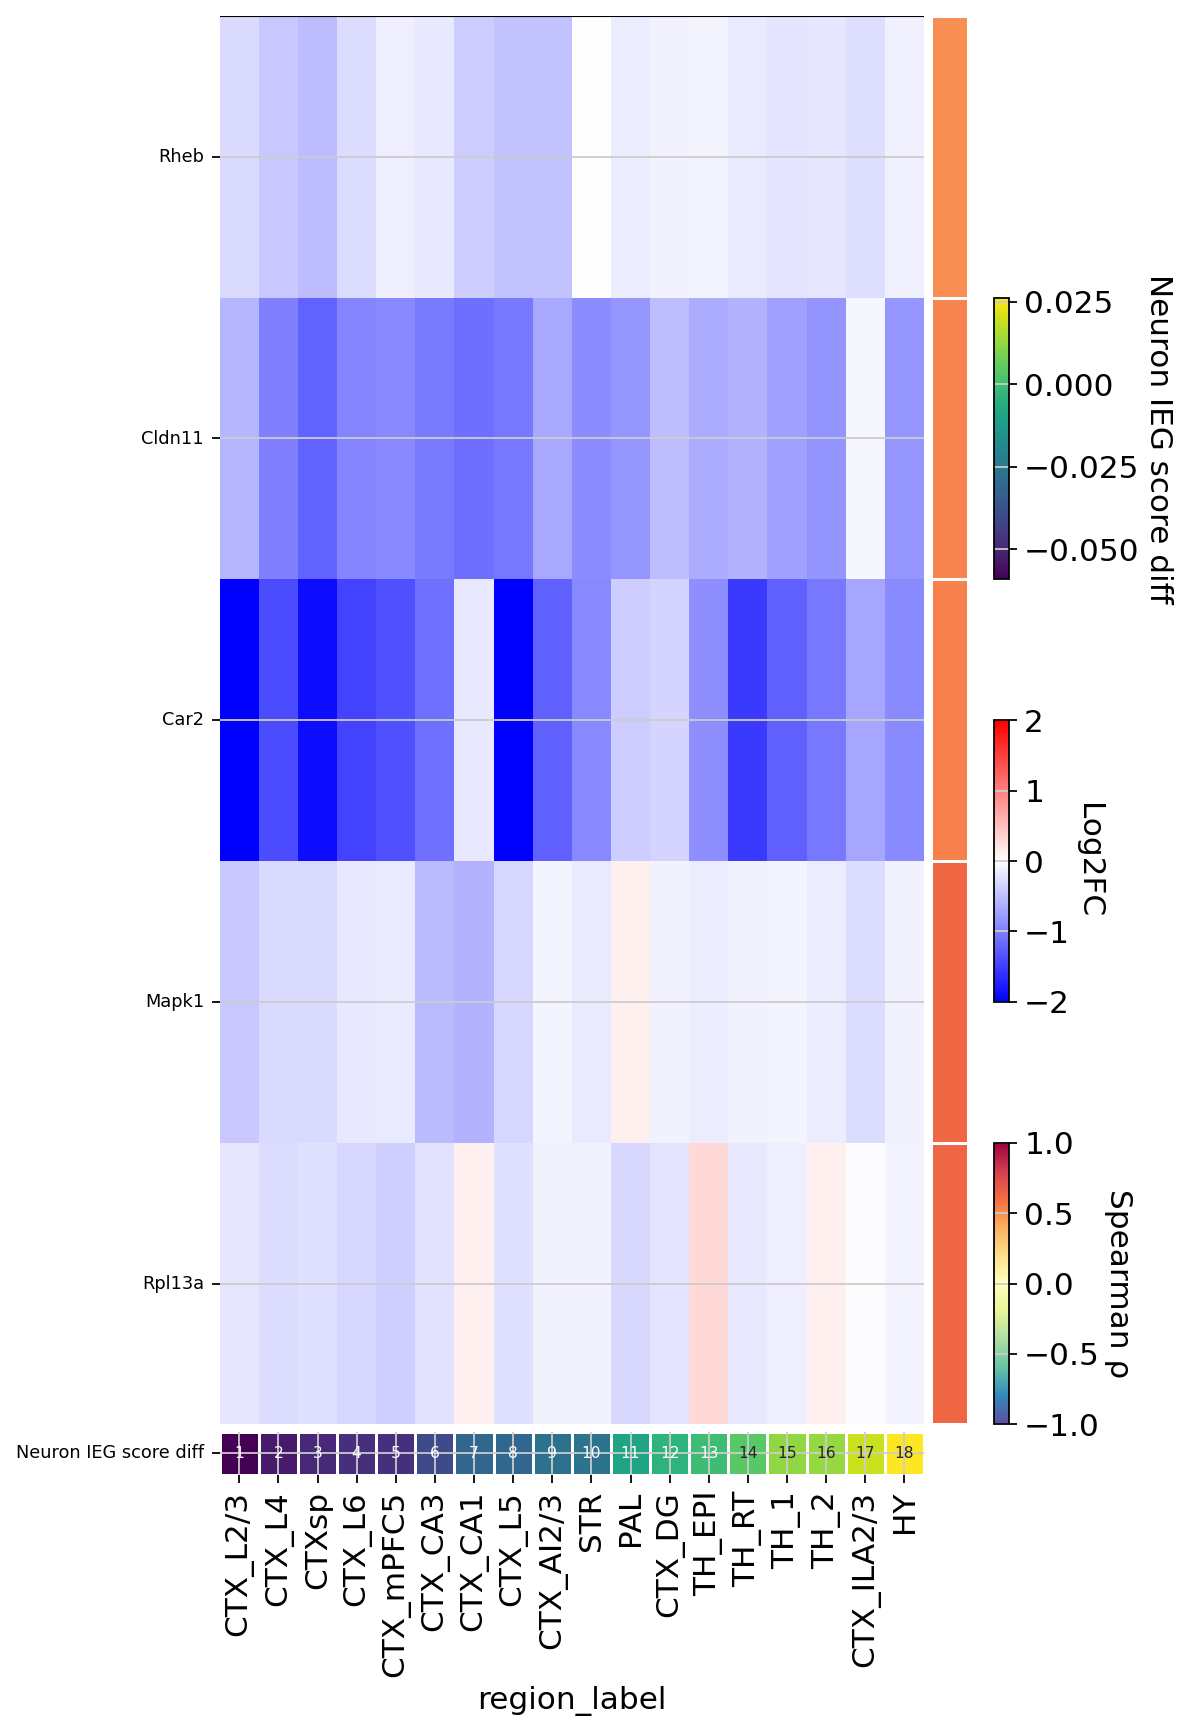

In [ ]:
# Figure & axes
fig = plt.figure(figsize=(6, 12))      
gs  = GridSpec(
        nrows=2, ncols=2,
        height_ratios=[.97, .03],       
        width_ratios =[.95, .05],
        hspace=0.01, wspace=0.02)

ax_main = fig.add_subplot(gs[0, 0])    
ax_rho = fig.add_subplot(gs[0, 1])    
ax_basal = fig.add_subplot(gs[1, 0]) 

fig.add_subplot(gs[1, 1]).axis('off')
    
# Expression heat-map
sns.heatmap(plot_df, cmap='bwr', vmin=-2, vmax=2, ax=ax_main, cbar=False,
                 cbar_kws={'label': 'Log2FC', 'shrink': 0.25, 'location': 'right'})

ax_main.set_xticks([])               
ax_main.set_xlabel('')
ax_main.set_yticks(genes_index)
ax_main.set_yticklabels(genes_to_label, rotation=0, fontsize=8)

# Add horizontal line
current_pos = coor_df.loc[coor_df['rho'] < 0, :].shape[0]
ax_main.axhline(y=current_pos, color='black', linewidth=.5, alpha=1)


# Rho heat-map
sns.heatmap(coor_df.loc[:, ['rho']], cmap='Spectral_r', vmin=-1, vmax=1, 
                  cbar=False, linewidth=.5, linecolor='white',
                  ax=ax_rho)
# Remove y-axis ticks for the second plot
ax_rho.set_yticks([])
ax_rho.set_yticklabels([])
ax_rho.set_xticks([])
ax_rho.set_xticklabels([])

# Basal expression
annot_data = [range(1, basal_df.shape[1] + 1)]
sns.heatmap(
    basal_df,
    cmap='viridis',            
    cbar=False,
    annot=annot_data,
    fmt='d',
    annot_kws={"size": 7},
    linewidth=.5, linecolor='white',
    ax=ax_basal)

ax_basal.set_yticklabels(['Neuron IEG score diff'], rotation=0, fontsize=8)

# Add colorbars for both subplots with proper positioning to avoid overlap
cax = ax_main.inset_axes([1.1, .6, 0.02, 0.2])
cbar1 = plt.colorbar(ax_basal.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar1.set_label('Neuron IEG score diff', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.1, .3, 0.02, 0.2])
cbar2 = plt.colorbar(ax_main.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar2.set_label('Log2FC', rotation=270, labelpad=15)

cax = ax_main.inset_axes([1.1, 0, 0.02, 0.2])
cbar3 = plt.colorbar(ax_rho.collections[0], cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar3.set_label('Spearman ρ', rotation=270, labelpad=15)

plt.savefig(os.path.join(fig_path, 'AD OLG DEG.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Activity-gene co-variation scatter plot

In [ ]:
protocol   = "RIBO"
obs_metric = "IEG_score"

data_dict = {}

for rgn in adata.obs["region_label"].unique():
    if rgn in region_to_exclude:
        continue

    ad_neu = adata[(adata.obs["spatial_analysis"])
                   & (adata.obs["region_label"] == rgn)
                   & (adata.obs["protocol"] == protocol)]

    neu_wt  = ad_neu[ad_neu.obs["condition"] == "WT"].obs[obs_metric].mean()
    neu_het = ad_neu[ad_neu.obs["condition"] == "HET"].obs[obs_metric].mean()
    region_row = {f"neuron_{obs_metric}": neu_het - neu_wt}

    data_dict[rgn] = region_row

logfc_df = (
    pd.DataFrame.from_dict(data_dict, orient="index")
      .rename_axis("region_label")
      .sort_index()
)

logfc_df 


,neuron_IEG_score
region_label,
CTX_AI2/3,-0.027286
CTX_CA1,-0.031420
CTX_CA3,-0.039956
CTX_DG,-0.003875
CTX_ILA2/3,0.019311
CTX_L2/3,-0.059099
CTX_L4,-0.053161
CTX_L5,-0.031022
CTX_L6,-0.047659


In [ ]:
ct_dict = pd.read_excel(f"{out_path}/glia_log2FC_by_region_RIBO.xlsx", sheet_name=None, index_col=0)

In [ ]:
color_map ={
    'SSC': '#2AB529',
    'PFC': '#F6C34C',
    'ST': '#00C1FD',
    'TH': '#f78a88',
    'HP': '#8B09BE',
    'Other': '#cccccc'
}

In [ ]:
rgn_dict = {'PFC': ['CTX_mPFC5', 'CTX_ILA2/3'],
            'SSC': ['CTX_L2/3','CTX_L4','CTX_L5','CTX_L6'],
            'ST': ['STR'],
            'HP': ['CTX_CA1', 'CTX_CA3', 'CTX_DG', 'CTX_HIP'],
            'TH': ['TH_1', 'TH_2', 'TH_EPI','TH_RT']
            }

In [ ]:
region_colors = {}
for rgn_group, rgn_list in rgn_dict.items():
    for rgn in rgn_list:
        region_colors[rgn] = color_map[rgn_group]
for rgn in adata.obs['region_label'].unique():
    if rgn not in region_colors:
        region_colors[rgn] = color_map['Other']

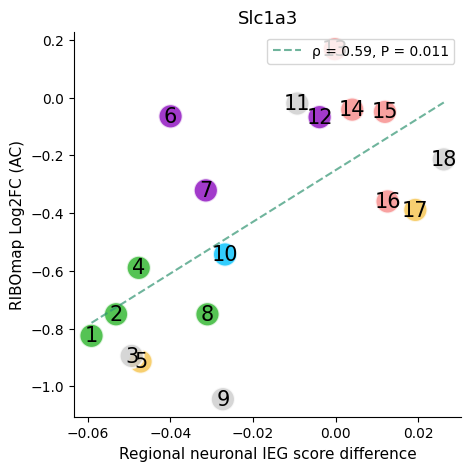

In [ ]:
gene = 'Slc1a3'
current_ct = 'AC'

merged_df = pd.merge(
    logfc_df,
    ct_dict[current_ct],
    on='region_label',
    how='inner'
)

df = merged_df
plt.figure(figsize=(5, 5))
ax = sns.scatterplot(
    data=df,
    x='neuron_IEG_score',
    y=gene,
    hue='region_label',
    palette=region_colors,
    s=300,
    alpha=0.8,
    legend = False
)

rho, pval = spearmanr(df['neuron_IEG_score'], df[gene])
slope, intercept, *_ = linregress(df['neuron_IEG_score'], df[gene])
x_vals = [df['neuron_IEG_score'].min(), df['neuron_IEG_score'].max()]
x_vals
y_vals = [slope * x + intercept for x in x_vals]

ax.plot(x_vals, y_vals, linestyle='--', color='#329573',
            label=f"ρ = {rho:.2f}, P = {pval:.2g}", alpha=0.7)


df['rank'] = df['neuron_IEG_score'].rank(ascending=True)

for _, row in df.iterrows():
    ax.annotate(int(row['rank']),  xy=(row['neuron_IEG_score'], row[gene],), 
                color='k', 
                fontsize=15, weight='medium',
                horizontalalignment='center',
                verticalalignment='center')

# Formatting
ax.set_title(f"{gene}", fontsize=13)
ax.set_xlabel("Regional neuronal IEG score difference", fontsize=11)
ax.set_ylabel(f"RIBOmap Log2FC ({current_ct})", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc='upper right')
plt.savefig(os.path.join(fig_path,'IEG corr',f'{gene}_{current_ct}.pdf'), format='pdf', dpi=300)
plt.show()